In [51]:
import sys
from tqdm import tqdm
# print(f"Python version: {sys.executable}")
import argparse
import os
from dataclasses import dataclass, field
import pathlib
from typing import Optional, Dict, Sequence, Tuple

import gymnasium as gym
import numpy as np
import torch
from torch.utils.tensorboard import SummaryWriter

from LCRL.env import DummyVectorEnv
from LCRL.exploration import GaussianNoise
from LCRL.data import Batch
from LCRL.utils.net.common import Net
from LCRL.utils.net.continuous import Actor, Critic
import LCRL.reach_rl_gym_envs as reach_rl_gym_envs

from env_utils import NoResetSyncVectorEnv, evaluate_V_batch, find_a_batch, find_a, get_args, get_env_and_policy
from intent_estimation_utils import ControlGainEstimator
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
plt.ion()
from matplotlib import cm

from gymnasium.vector import SyncVectorEnv
from copy import deepcopy
from gymnasium.vector.utils import concatenate
from mppi_mpc_controller import (
    DroneMPPIConfig,
    DroneMPPIController,
    ReachabilityValueFunction,
)
from mpc_cbf_controller import DroneMPCConfig, DroneMPCCBFController

from mppi_mpc_cbf_controller import (
    MPPI_MPC_CBF_ControllerConfig,
    MPPI_MPC_CBF_Controller,
)

from scipy.interpolate import RegularGridInterpolator

from local_verif_utils import get_beta5, beta, calibrate_V_vectorized, calibrate_V_scenario_local_vectorized, grow_regions_closest_point, make_new_env, compute_min_scenarios_alex
from time import time

# set random seeds for reproducibility
np.random.seed(0)
torch.manual_seed(0)

from local_verif_switch_policy import plot_trajectories, DroneRaceSimulation, extract_xy, target_set

In [365]:
def get_opponent_stop_idx(states: np.ndarray,
                          tol=1e-5):
    """
    Return last index where opponent is still moving
    """
    opp_pos = states[:, [6, 8, 10]]

    diffs = np.linalg.norm(opp_pos[1:] - opp_pos[:-1], axis=1)

    moving = diffs > tol

    if not np.any(moving):
        return 0  # opponent is stationary from the start
    
    last_moving_idx = np.where(moving)[0][-1] + 1  # +1 to get the index in the original states array
    return last_moving_idx



def plot_trajectories(
    states: np.ndarray,
    # modes: np.ndarray,
    # expanded_regions: list[Tuple[float, float, float]],
    # sim: DroneRaceSimulation,
    num_agents: int,
    controlled_agent: int,
    per_agent_state_dim: int,
    expanded_regions: list[Tuple[float, float, float]] = None,
    modes: np.ndarray = None,
    mppi_baseline_states: np.ndarray = None,
    mppi_cbf_baseline_states: np.ndarray = None,
    save_path: pathlib.Path | None = None,
    gif_path: pathlib.Path | None = None,
    fps: int = 20,
) -> None:
    """Plot ego/opponent xy-trajectories and the quarter-circle reference."""
    print(f"expanded_regions len: {len(expanded_regions) if expanded_regions is not None else 'None'}")

    # controller = sim.controller
    # per_agent_state_dim = controller.per_agent_state_dim
    # per_agent_state_dim = controller.mppi_controller_fast.per_agent_state_dim

    fig, ax = plt.subplots(figsize=(6, 6))

    # vel magnitude per agent
    max_speeds = []
    max_speeds_mppi_baseline = []
    max_speeds_mppi_cbf_baseline = []
    for idx in range(num_agents):
        if idx == controlled_agent:
            sl = slice(idx * per_agent_state_dim, (idx + 1) * per_agent_state_dim)
            vel = states[:, sl][:, [1, 3, 5]]
            vel_mppi_baseline = mppi_baseline_states[:, sl][:, [1, 3, 5]] if mppi_baseline_states is not None else None
            vel_mppi_cbf_baseline = mppi_cbf_baseline_states[:, sl][:, [1, 3, 5]] if mppi_cbf_baseline_states is not None else None
            speed = np.linalg.norm(vel, axis=1)
            speed_mppi_baseline = np.linalg.norm(vel_mppi_baseline, axis=1) if mppi_baseline_states is not None else None
            speed_mppi_cbf_baseline = np.linalg.norm(vel_mppi_cbf_baseline, axis=1) if mppi_cbf_baseline_states is not None else None
            max_speeds.append(speed.max())
            max_speeds_mppi_baseline.append(speed_mppi_baseline.max()) if mppi_baseline_states is not None else None
            max_speeds_mppi_cbf_baseline.append(speed_mppi_cbf_baseline.max()) if mppi_cbf_baseline_states is not None else None

    # # Reference quarter-circle
    # ref_xy = sim.reference[:, ::2][:, :2]
    # print(f"Ref xy shape: {ref_xy.shape}")
    # ax.plot(ref_xy[:, 0], ref_xy[:, 1], "--", color="grey", label="Reference")

    colours = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
    labels = []
    labels_mppi_baseline = []
    labels_mppi_cbf_baseline = []
    for idx in range(num_agents):
        x, y = extract_xy(states, idx, per_agent_state_dim)
        x_mppi_baseline, y_mppi_baseline = extract_xy(mppi_baseline_states, idx, per_agent_state_dim) if mppi_baseline_states is not None else (None, None)
        x_mppi_cbf_baseline, y_mppi_cbf_baseline = extract_xy(mppi_cbf_baseline_states, idx, per_agent_state_dim) if mppi_cbf_baseline_states is not None else (None, None)
        lbl = "Ego agent" if idx == controlled_agent else f"Agent {idx}"
        labels.append(ax.plot(x, y, color=colours[idx % len(colours)], label=lbl)[0])
        labels_mppi_baseline.append(ax.plot(x_mppi_baseline, y_mppi_baseline, color=colours[idx % len(colours)], linestyle="--", label=f"{lbl} (mppi baseline)")[0]) if mppi_baseline_states is not None else None
        labels_mppi_cbf_baseline.append(ax.plot(x_mppi_cbf_baseline, y_mppi_cbf_baseline, color=colours[idx % len(colours)], linestyle=":", label=f"{lbl} (mppi cbf baseline)")[0]) if mppi_cbf_baseline_states is not None else None
    

    ax.scatter(0.0, 0.0, marker="s", color="black", label="Gate (origin)")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_aspect("equal", adjustable="box")
    ax.set_title("MPPI Drone Trajectory")
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.set_xlim(-0.9, 0.9)
    ax.set_ylim(-2.6, 0.2)
    ax.legend()

    print("Maximum speeds (m/s) per agent:")
    # for idx, ms in enumerate(max_speeds):
    if mppi_baseline_states is not None:
        # for idx, (ms, ms_baseline) in enumerate(zip(max_speeds, max_speeds_mppi_baseline)):
        for idx, (ms, ms_baseline, ms_cbf_baseline) in enumerate(zip(max_speeds, max_speeds_mppi_baseline, max_speeds_mppi_cbf_baseline)):
            tag = "Switching Controller agent" if idx == controlled_agent else f"Agent {idx}"
            tag_baseline = f"{tag} (MPPI baseline)"
            tag_cbf_baseline = f"{tag} (MPPI CBF baseline)"
            print(f"  {tag}: {ms:.3f}")
            print(f"  {tag_baseline}: {ms_baseline:.3f}")
            print(f"  {tag_cbf_baseline}: {ms_cbf_baseline:.3f}")

    if save_path is not None:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    else:
        plt.show()
    plt.close(fig)

    if gif_path is not None:
        gif_path.parent.mkdir(parents=True, exist_ok=True)
        metadata = {"title": "Drone MPPI", "artist": "visualize_mppi_traj"}
        fig_gif, ax_gif = plt.subplots(figsize=(6, 6))
        ax_gif.set_xlim(ax.get_xlim())
        ax_gif.set_ylim(ax.get_ylim())
        ax_gif.set_aspect("equal", adjustable="box")
        ax_gif.grid(True, linestyle="--", alpha=0.3)
        ax_gif.set_xlabel("x [m]")
        ax_gif.set_ylabel("y [m]")
        ax_gif.set_title("MPPI Drone Trajectory Animation")

        # ref_line, = ax_gif.plot(ref_xy[:, 0], ref_xy[:, 1], "--", color="grey", label="Reference")
        gate_marker, = ax_gif.plot(0.0, 0.0, "s", color="black", label="Gate")

        trajectories = []
        velocities = []
        speed_components = []

        # trajectories_baseline = []
        # velocities_baseline = []
        # speed_components_baseline = []
        modes_list = list(modes) if modes is not None else [None] * states.shape[0]
        # got_idx_other = False
        for idx in range(num_agents):
            # if (idx == controlled_agent and mppi_baseline_states is not None) or (mppi_baseline_states is None):
            x_hybrid, y_hybrid = extract_xy(states, idx, per_agent_state_dim)
            sl = slice(idx * per_agent_state_dim, (idx + 1) * per_agent_state_dim)
            agent_states = states[:, sl]
            vx_hybrid = agent_states[:, 1]
            vy_hybrid = agent_states[:, 3]
            vz_hybrid = agent_states[:, 5]
            if idx == controlled_agent:
                trajectories.append((x_hybrid, y_hybrid))
                velocities.append((vx_hybrid, vy_hybrid))
                speed_components.append((vx_hybrid, vy_hybrid, vz_hybrid))

            x_baseline, y_baseline = extract_xy(mppi_baseline_states, idx, per_agent_state_dim) if mppi_baseline_states is not None else (None, None)
            agent_states_baseline = mppi_baseline_states[:, sl] if mppi_baseline_states is not None else None
            vx_baseline = agent_states_baseline[:, 1] if agent_states_baseline is not None else None
            vy_baseline = agent_states_baseline[:, 3] if agent_states_baseline is not None else None
            vz_baseline = agent_states_baseline[:, 5] if agent_states_baseline is not None else None
            if idx == controlled_agent and mppi_baseline_states is not None:
                trajectories.append((x_baseline, y_baseline))
                velocities.append((vx_baseline, vy_baseline))
                speed_components.append((vx_baseline, vy_baseline, vz_baseline))

            # if idx != controlled_agent and not got_idx_other:
            #     got_idx_other = True

            x_cbf, y_cbf = extract_xy(mppi_cbf_baseline_states, idx, per_agent_state_dim) if mppi_cbf_baseline_states is not None else (None, None)
            agent_states_cbf_baseline = mppi_cbf_baseline_states[:, sl] if mppi_cbf_baseline_states is not None else None
            vx_cbf_baseline = agent_states_cbf_baseline[:, 1] if agent_states_cbf_baseline is not None else None
            vy_cbf_baseline = agent_states_cbf_baseline[:, 3] if agent_states_cbf_baseline is not None else None
            vz_cbf_baseline = agent_states_cbf_baseline[:, 5] if agent_states_cbf_baseline is not None else None
            if idx == controlled_agent and mppi_cbf_baseline_states is not None:
                trajectories.append((x_cbf, y_cbf))
                velocities.append((vx_cbf_baseline, vy_cbf_baseline))
                speed_components.append((vx_cbf_baseline, vy_cbf_baseline, vz_cbf_baseline))


            if idx != controlled_agent:
                # for other agent choose trajectory that lasts the longest (in case of early stopping)
                all_trajectories = [states, mppi_baseline_states, mppi_cbf_baseline_states]
                stop_indices = [
                    get_opponent_stop_idx(traj) if traj is not None else 0
                    for traj in all_trajectories
                ]
                best_idx = np.argmax(stop_indices)
                if best_idx == 0:
                    trajectories.append((x_hybrid, y_hybrid))
                    velocities.append((vx_hybrid, vy_hybrid))
                    speed_components.append((vx_hybrid, vy_hybrid, vz_hybrid))
                else:
                    best_traj = all_trajectories[best_idx]
                    x_best, y_best = extract_xy(best_traj, idx, per_agent_state_dim)
                    agent_states_best = best_traj[:, sl]
                    vx_best = agent_states_best[:, 1]
                    vy_best = agent_states_best[:, 3]
                    vz_best = agent_states_best[:, 5]
                    trajectories.append((x_best, y_best))
                    velocities.append((vx_best, vy_best))
                    speed_components.append((vx_best, vy_best, vz_best))
            
        # trajectory order: ego hybrid, ego mppi baseline (if exists), ego mppi cbf baseline (if exists), other agent 

        lines = []
        quivers = []
        speed_texts = []
        # contourf_list = []
        # contour_list = []
        for idx in range(num_agents):
            colour = colours[idx % len(colours)]
            lbl = "Ego agent (Switching)" if idx == controlled_agent else f"Agent {idx}"
            line, = ax_gif.plot([], [], color=colour, label=lbl)
            marker, = ax_gif.plot([], [], "o", color=colour)
            # contourf, = ax_gif.contourf([], [], [], levels=[1-1e-6, 1], colors=["lightgreen"], alpha=0.3)
            # contour, = ax_gif.contour([], [], [], levels=[1-1e-6], colors=["green"], alpha=0.5, linewidths=1)
            quiver = ax_gif.quiver(
                [],
                [],
                [],
                [],
                color=colour,
                angles="xy",
                scale_units="xy",
                scale=1.0,
                width=0.005,
            )
            lines.append((line, marker))
            quivers.append(quiver)
            # contourf_list.append(contourf)
            # contour_list.append(contour)
            text = ax_gif.text(
                0.0,
                0.0,
                "",
                color=colour,
                fontsize=9,
                ha="left",
                va="bottom",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.6, edgecolor="none"),
            )
            speed_texts.append(text)

            if idx == controlled_agent and mppi_baseline_states is not None:
                colour_baseline = colour
                lbl_baseline = f"Ego agent (MPPI baseline)"
                line_baseline, = ax_gif.plot([], [], color=colour_baseline, linestyle="--", label=lbl_baseline)
                marker_baseline, = ax_gif.plot([], [], "o", color=colour_baseline, linestyle="--")
                quiver_baseline = ax_gif.quiver(
                    [],
                    [],
                    [],
                    [],
                    color=colour_baseline,
                    angles="xy",
                    scale_units="xy",
                    scale=1.0,
                    width=0.005,
                    linestyle="--"
                )
                lines.append((line_baseline, marker_baseline))
                quivers.append(quiver_baseline)
                text_baseline = ax_gif.text(
                    0.0,
                    0.0,
                    "",
                    color=colour_baseline,
                    fontsize=9,
                    ha="left",
                    va="bottom",
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.6, edgecolor="none"),
                )
                speed_texts.append(text_baseline)

            if idx == controlled_agent and mppi_cbf_baseline_states is not None:
                colour_cbf_baseline = colour
                lbl_cbf_baseline = f"Ego agent (MPPI CBF baseline)"
                line_cbf_baseline, = ax_gif.plot([], [], color=colour_cbf_baseline, linestyle=":", label=lbl_cbf_baseline)
                marker_cbf_baseline, = ax_gif.plot([], [], "o", color=colour_cbf_baseline, linestyle=":")
                quiver_cbf_baseline = ax_gif.quiver(
                    [],
                    [],
                    [],
                    [],
                    color=colour_cbf_baseline,
                    angles="xy",
                    scale_units="xy",
                    scale=1.0,
                    width=0.005,
                    linestyle=":"
                )
                lines.append((line_cbf_baseline, marker_cbf_baseline))
                quivers.append(quiver_cbf_baseline)
                text_cbf_baseline = ax_gif.text(
                    0.0,
                    0.0,
                    "",
                    color=colour_cbf_baseline,
                    fontsize=9,
                    ha="left",
                    va="bottom",
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.6, edgecolor="none"),
                )
                speed_texts.append(text_cbf_baseline)

        # # plot target set in gif
        # x = np.arange(-0.9, 0.9, 0.01)
        # y = np.arange(-2.6, 0.0, 0.01)
        # X, Y = np.meshgrid(x, y)
        # for state in states:
        #     tmp_point = state.copy()
        #     Z = target_set(X, Y, tmp_point)
        #     ax_gif.contourf(X, Y, Z, levels=[1-1e-6, 1], colors=["lightgreen"], alpha=0.3)
        #     ax_gif.contour(X, Y, Z, levels=[1-1e-6, 1], colors=["green"], alpha=0.5, linewidths=1)

        ax_gif.legend()

        def init():
            artists = []
            # artists.extend([ref_line, gate_marker])
            for (line, marker), quiver, text in zip(lines, quivers, speed_texts):
                line.set_data([], [])
                marker.set_data([], [])
                quiver.set_offsets(np.empty((0, 2)))
                quiver.set_UVC([], [])
                text.set_text("")
                artists.extend([line, marker, quiver, text])
            return artists

        vel_arrow_scale = 0.5  # scales arrow length for visual clarity

        def update(frame: int):
            nonlocal contour, contourf
            artists = []
            x = np.arange(-0.9, 0.9, 0.01)
            y = np.arange(-2.6, 0.0, 0.01)
            X, Y = np.meshgrid(x, y)
            
            for i, (
                (line, marker),
                quiver,
                text,
                (x_hist, y_hist),
                (vx_hist, vy_hist),
                (vx_comp, vy_comp, vz_comp),
                # (x_hist_baseline, y_hist_baseline),
                # (vx_hist_baseline, vy_hist_baseline),
                # (vx_comp_baseline, vy_comp_baseline, vz_comp_baseline),
            ) in enumerate(zip(
                lines, quivers, speed_texts, trajectories, velocities, speed_components, #trajectories_baseline, velocities_baseline, speed_components_baseline 
            )):
                line.set_data(x_hist[: frame + 1], y_hist[: frame + 1])
                marker.set_data([x_hist[frame]], [y_hist[frame]])
                # include expanded region circle if not None for each frame
                # print(f"Agent {i}")
                if i == 0:  # only plot for ego agent
                    expanded_region = expanded_regions[frame] if expanded_regions is not None else None
                    if expanded_region is not None:
                        x_center, y_center, r_safe = expanded_region
                        circle = plt.Circle((x_center, y_center), r_safe, color='blue', fill=False, linestyle='dashed', label='Expanded Region')
                        # remove previous circle if exists
                        existing_circles = [artist for artist in ax_gif.patches if isinstance(artist, plt.Circle)]
                        for ec in existing_circles:
                            ec.remove()
                        # ax_gif.add_artist(circle)
                        ax_gif.add_patch(circle)
                    else:
                        # remove previous circle if exists
                        existing_circles = [artist for artist in ax_gif.patches if isinstance(artist, plt.Circle)]
                        for ec in existing_circles:
                            ec.remove()

                # update target set contours
                # tmp_point = states[frame].copy()
                tmp_point = mppi_baseline_states[frame].copy() if mppi_baseline_states is not None else states[frame].copy()
                Z = target_set(X, Y, tmp_point)
                if contourf is not None:
                    for c in contourf.collections:
                        c.remove()
                if contour is not None:
                    for c in contour.collections:
                        c.remove()
                # for c in contourf.collections:
                #     c.remove()
                # for c in contour.collections:
                #     c.remove()
                contourf = ax_gif.contourf(X, Y, Z, levels=[1-1e-6, 1], colors=["lightgreen"], alpha=0.3)
                contour = ax_gif.contour(X, Y, Z, levels=[1-1e-6, 1], colors=["green"], alpha=0.5, linewidths=1)



                vx = vx_hist[frame] * vel_arrow_scale
                vy = vy_hist[frame] * vel_arrow_scale
                quiver.set_offsets(np.array([[x_hist[frame], y_hist[frame]]]))
                quiver.set_UVC(np.array([vx]), np.array([vy]))
                speed = np.sqrt(
                    vx_comp[frame] ** 2 + vy_comp[frame] ** 2 + vz_comp[frame] ** 2
                )
                text.set_position((x_hist[frame] + 0.05, y_hist[frame] + 0.05))
                # text.set_text(f"{speed:.2f} m/s")
                mode = modes_list[frame] if modes_list is not None else None
                text.set_text(f"Mode: {mode}, Speed: {speed:.2f} m/s") if i == 0 else text.set_text(f"Speed: {speed:.2f} m/s")
                artists.extend([line, marker, quiver, text])
            
            # for i, (
            #     (line, marker),
            #     quiver,
            #     text,
            #     (x_hist_baseline, y_hist_baseline),
            #     (vx_hist_baseline, vy_hist_baseline),
            #     (vx_comp_baseline, vy_comp_baseline, vz_comp_baseline),
            # ) in enumerate(zip(
            #     lines, quivers, speed_texts, trajectories_baseline, velocities_baseline, speed_components_baseline
            # )):
            #     if len(x_hist_baseline) > 0:
            #         line.set_data(x_hist_baseline[: frame + 1], y_hist_baseline[: frame + 1])
            #         marker.set_data([x_hist_baseline[frame]], [y_hist_baseline[frame]])
            #         vx = vx_hist_baseline[frame] * vel_arrow_scale
            #         vy = vy_hist_baseline[frame] * vel_arrow_scale
            #         quiver.set_offsets(np.array([[x_hist_baseline[frame], y_hist_baseline[frame]]]))
            #         quiver.set_UVC(np.array([vx]), np.array([vy]))
            #         speed = np.sqrt(
            #             vx_comp_baseline[frame] ** 2 + vy_comp_baseline[frame] ** 2 + vz_comp_baseline[frame] ** 2
            #         )
            #         text.set_position((x_hist_baseline[frame] + 0.05, y_hist_baseline[frame] + 0.05))
            #         text.set_text(f"Speed: {speed:.2f} m/s")
            #         artists.extend([line, marker, quiver, text])
            
            
            return artists

        from matplotlib import animation

        blit_flag = gif_path is None
        contour = None
        contourf = None
        anim = animation.FuncAnimation(
            fig_gif,
            update,
            init_func=init,
            frames=states.shape[0],
            interval=1000 / fps,
            blit=blit_flag,
        )
        writer = animation.PillowWriter(fps=fps, metadata=metadata)
        anim.save(gif_path, writer=writer, dpi=100)
        plt.close(fig_gif)


In [509]:
# def plot_trajectories_new(
#     states: np.ndarray,
#     # modes: np.ndarray,
#     # expanded_regions: list[Tuple[float, float, float]],
#     # sim: DroneRaceSimulation,
#     num_agents: int,
#     controlled_agent: int,
#     per_agent_state_dim: int,
#     expanded_regions: list[Tuple[float, float, float]] = None,
#     modes: np.ndarray = None,
#     # mppi_baseline_states: np.ndarray = None,
#     # mppi_cbf_baseline_states: np.ndarray = None,
#     baseline_dict: Dict[str, Optional[np.ndarray]] = None,
#     save_path: pathlib.Path | None = None,
#     gif_path: pathlib.Path | None = None,
#     fps: int = 20,
# ) -> None:
#     """Plot ego/opponent xy-trajectories and the quarter-circle reference."""
#     print(f"expanded_regions len: {len(expanded_regions) if expanded_regions is not None else 'None'}")

#     # controller = sim.controller
#     # per_agent_state_dim = controller.per_agent_state_dim
#     # per_agent_state_dim = controller.mppi_controller_fast.per_agent_state_dim
#     STYLE_MAP = {
#         "mppi_baseline": "--",
#         "mppi_cbf_baseline": ":",
#         "mppi_safe_baseline": "-.",
#         "mppi_warmstart_learned_baseline": (0, (3, 1, 1, 1)),
#         "policy_only_baseline": (0, (5, 1)),
#         "hybrid_no_learned_policy_baseline": (0, (1, 1))
#     }
#     fig, ax = plt.subplots(figsize=(6, 6))

#     # vel magnitude per agent
#     max_speeds = []
#     max_speeds_mppi_baseline = []
#     max_speeds_mppi_cbf_baseline = []
#     max_speeds_mppi_safe_baseline = []
#     max_speeds_mppi_warmstart_learned_baseline = []
#     max_speeds_policy_only = []
#     max_speeds_learned_policy_ablation = []
#     for idx in range(num_agents):
#         if idx == controlled_agent:
#             sl = slice(idx * per_agent_state_dim, (idx + 1) * per_agent_state_dim)
#             vel = states[:, sl][:, [1, 3, 5]]
#             vel_mppi_baseline = baseline_dict["mppi_baseline"][:, sl][:, [1, 3, 5]] if "mppi_baseline" in baseline_dict else None
#             vel_mppi_cbf_baseline = baseline_dict["mppi_cbf"][:, sl][:, [1, 3, 5]] if "mppi_cbf" in baseline_dict else None
#             vel_mppi_safe_baseline = baseline_dict["mppi_safe_baseline"][:, sl][:, [1, 3, 5]] if "mppi_safe_baseline" in baseline_dict else None
#             vel_mppi_warmstart_learned_baseline = baseline_dict["mppi_warmstart_learned_baseline"][:, sl][:, [1, 3, 5]] if "mppi_warmstart_learned_baseline" in baseline_dict else None
#             vel_policy_only_baseline = baseline_dict["policy_only_baseline"][:, sl][:, [1, 3, 5]] if "policy_only_baseline" in baseline_dict else None
#             vel_learned_policy_ablation_baseline = baseline_dict["hybrid_no_learned_policy"][:, sl][:, [1, 3, 5]] if "hybrid_no_learned_policy" in baseline_dict else None

#             speed = np.linalg.norm(vel, axis=1)
#             speed_mppi_baseline = np.linalg.norm(vel_mppi_baseline, axis=1) if vel_mppi_baseline is not None else None
#             speed_mppi_cbf_baseline = np.linalg.norm(vel_mppi_cbf_baseline, axis=1) if vel_mppi_cbf_baseline is not None else None
#             speed_mppi_safe_baseline = np.linalg.norm(vel_mppi_safe_baseline, axis=1) if vel_mppi_safe_baseline is not None else None
#             speed_mppi_warmstart_learned_baseline = np.linalg.norm(vel_mppi_warmstart_learned_baseline, axis=1) if vel_mppi_warmstart_learned_baseline is not None else None
#             speed_policy_only_baseline = np.linalg.norm(vel_policy_only_baseline, axis=1) if vel_policy_only_baseline is not None else None
#             speed_learned_policy_ablation_baseline = np.linalg.norm(vel_learned_policy_ablation_baseline, axis=1) if vel_learned_policy_ablation_baseline is not None else None

#             max_speeds.append(speed.max())
#             max_speeds_mppi_baseline.append(speed_mppi_baseline.max()) if vel_mppi_baseline is not None else None
#             max_speeds_mppi_cbf_baseline.append(speed_mppi_cbf_baseline.max()) if vel_mppi_cbf_baseline is not None else None
#             max_speeds_mppi_safe_baseline.append(speed_mppi_safe_baseline.max()) if vel_mppi_safe_baseline is not None else None
#             max_speeds_mppi_warmstart_learned_baseline.append(speed_mppi_warmstart_learned_baseline.max()) if vel_mppi_warmstart_learned_baseline is not None else None
#             max_speeds_policy_only.append(speed_policy_only_baseline.max()) if vel_policy_only_baseline is not None else None
#             max_speeds_learned_policy_ablation.append(speed_learned_policy_ablation_baseline.max()) if vel_learned_policy_ablation_baseline is not None else None
#     # # Reference quarter-circle
#     # ref_xy = sim.reference[:, ::2][:, :2]
#     # print(f"Ref xy shape: {ref_xy.shape}")
#     # ax.plot(ref_xy[:, 0], ref_xy[:, 1], "--", color="grey", label="Reference")

#     colours = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
#     labels = []
#     labels_baselines = {key: [] for key in baseline_dict.keys()} if baseline_dict is not None else {}
#     key_order = list(baseline_dict.keys()) if baseline_dict is not None else []
#     for idx in range(num_agents):
#         x, y = extract_xy(states, idx, per_agent_state_dim)
#         # x_mppi_baseline, y_mppi_baseline = extract_xy(mppi_baseline_states, idx, per_agent_state_dim) if mppi_baseline_states is not None else (None, None)
#         # x_mppi_cbf_baseline, y_mppi_cbf_baseline = extract_xy(mppi_cbf_baseline_states, idx, per_agent_state_dim) if mppi_cbf_baseline_states is not None else (None, None)
#         lbl = "Ego agent" if idx == controlled_agent else f"Agent {idx}"
#         labels.append(ax.plot(x, y, color=colours[idx % len(colours)], label=lbl)[0])
#         # labels_mppi_baseline.append(ax.plot(x_mppi_baseline, y_mppi_baseline, color=colours[idx % len(colours)], linestyle="--", label=f"{lbl} (mppi baseline)")[0]) if mppi_baseline_states is not None else None
#         # labels_mppi_cbf_baseline.append(ax.plot(x_mppi_cbf_baseline, y_mppi_cbf_baseline, color=colours[idx % len(colours)], linestyle=":", label=f"{lbl} (mppi cbf baseline)")[0]) if mppi_cbf_baseline_states is not None else None
        
#         # iterate through baseline_dict to plot any baselines that exist
#         if baseline_dict is not None:
#             # for key, traj_data in baseline_dict.items():
#             for key in key_order:
#                 traj_data = baseline_dict[key]
#                 x_baseline, y_baseline = extract_xy(traj_data, idx, per_agent_state_dim) if traj_data is not None else (None, None)
#                 # linestyle = "--" if "mppi_baseline" in key else ":" if "cbf" in key else "-." if "safe" in key else (0, (3, 1, 1, 1)) if "warmstart_learned" in key else (0, (5, 1)) if "policy_only" in key else (0, (1, 1))
#                 linestyle = STYLE_MAP[key] if key in STYLE_MAP else "--"
#                 lbl_baseline = f"{lbl} ({key.replace('_', ' ')})"
#                 line = ax.plot(x_baseline, y_baseline, color=colours[idx % len(colours)], linestyle=linestyle, label=lbl_baseline)[0] if traj_data is not None else None
#                 labels_baselines[key].append(line) if traj_data is not None else None

    

#     ax.scatter(0.0, 0.0, marker="s", color="black", label="Gate (origin)")
#     ax.set_xlabel("x [m]")
#     ax.set_ylabel("y [m]")
#     ax.set_aspect("equal", adjustable="box")
#     ax.set_title("MPPI Drone Trajectory")
#     ax.grid(True, linestyle="--", alpha=0.3)
#     ax.set_xlim(-0.9, 0.9)
#     ax.set_ylim(-2.6, 0.2)
#     ax.legend()

#     print("Maximum speeds (m/s) per agent:")
#     for idx, ms in enumerate(max_speeds):
#         tag = "Switching Controller agent" if idx == controlled_agent else f"Agent {idx}"
#         print(f"  {tag}: {ms:.3f}")
    
#     # for key in baseline_dict.keys():
#     for key in key_order:
#         ms_baseline = max_speeds_mppi_baseline if "mppi_baseline" in key else max_speeds_mppi_cbf_baseline if "cbf" in key else max_speeds_mppi_safe_baseline if "safe" in key else max_speeds_mppi_warmstart_learned_baseline if "warmstart_learned" in key else max_speeds_policy_only if "policy_only" in key else max_speeds_learned_policy_ablation if "hybrid_no_learned_policy" in key else None
#         if ms_baseline is not None:
#             print(f"  {key} maximum speeds:")
#             for idx, ms_b in enumerate(ms_baseline):
#                 tag = "Switching Controller agent" if idx == controlled_agent else f"Agent {idx}"
#                 print(f"    {tag} ({key}): {ms_b:.3f}")
    


#     if save_path is not None:
#         save_path.parent.mkdir(parents=True, exist_ok=True)
#         fig.savefig(save_path, dpi=150, bbox_inches="tight")
#     else:
#         plt.show()
#     plt.close(fig)

#     if gif_path is not None:
        
#         gif_path.parent.mkdir(parents=True, exist_ok=True)
#         metadata = {"title": "Drone MPPI", "artist": "visualize_mppi_traj"}
#         fig_gif, ax_gif = plt.subplots(figsize=(8, 8))
#         plt.subplots_adjust(right=0.55)
#         ax_gif.set_xlim(ax.get_xlim())
#         ax_gif.set_ylim(ax.get_ylim())
#         ax_gif.set_aspect("equal", adjustable="box")
#         ax_gif.grid(True, linestyle="--", alpha=0.3)
#         ax_gif.set_xlabel("x [m]")
#         ax_gif.set_ylabel("y [m]")
#         ax_gif.set_title("MPPI Drone Trajectory Animation")

#         # ref_line, = ax_gif.plot(ref_xy[:, 0], ref_xy[:, 1], "--", color="grey", label="Reference")
#         gate_marker, = ax_gif.plot(0.0, 0.0, "s", color="black", label="Gate")

#         trajectories = []
#         velocities = []
#         speed_components = []
#         # key_order = []
#         # key_order = list(baseline_dict.keys()) if baseline_dict is not None else []

#         # trajectories_baseline = []
#         # velocities_baseline = []
#         # speed_components_baseline = []
#         modes_list = list(modes) if modes is not None else [None] * states.shape[0]
#         # got_idx_other = False
#         for idx in range(num_agents):
#             # if (idx == controlled_agent and mppi_baseline_states is not None) or (mppi_baseline_states is None):
#             x_hybrid, y_hybrid = extract_xy(states, idx, per_agent_state_dim)
#             sl = slice(idx * per_agent_state_dim, (idx + 1) * per_agent_state_dim)
#             agent_states = states[:, sl]
#             vx_hybrid = agent_states[:, 1]
#             vy_hybrid = agent_states[:, 3]
#             vz_hybrid = agent_states[:, 5]
#             if idx == controlled_agent:
#                 trajectories.append((x_hybrid, y_hybrid))
#                 velocities.append((vx_hybrid, vy_hybrid))
#                 speed_components.append((vx_hybrid, vy_hybrid, vz_hybrid))

#             # for baseline_key in baseline_dict.keys():
#             for baseline_key in key_order:
#                 # key_order.append(baseline_key)
#                 traj_data = baseline_dict[baseline_key]
#                 x_baseline, y_baseline = extract_xy(traj_data, idx, per_agent_state_dim) if traj_data is not None else (None, None)
#                 agent_states_baseline = traj_data[:, sl] if traj_data is not None else None
#                 vx_baseline = agent_states_baseline[:, 1] if agent_states_baseline is not None else None
#                 vy_baseline = agent_states_baseline[:, 3] if agent_states_baseline is not None else None
#                 vz_baseline = agent_states_baseline[:, 5] if agent_states_baseline is not None else None
#                 if idx == controlled_agent and traj_data is not None:
#                     trajectories.append((x_baseline, y_baseline))
#                     velocities.append((vx_baseline, vy_baseline))
#                     speed_components.append((vx_baseline, vy_baseline, vz_baseline))
                
#             if idx != controlled_agent:
#                 # for other agent choose trajectory that lasts the longest (in case of early stopping)
#                 all_trajectories = [states] + [baseline_dict[key] for key in baseline_dict.keys()]
#                 stop_indices = [
#                     get_opponent_stop_idx(traj) if traj is not None else 0
#                     for traj in all_trajectories
#                 ]
#                 best_idx = np.argmax(stop_indices)
#                 best_traj = all_trajectories[best_idx]
#                 x_best, y_best = extract_xy(best_traj, idx, per_agent_state_dim)
#                 agent_states_best = best_traj[:, sl]
#                 vx_best = agent_states_best[:, 1]
#                 vy_best = agent_states_best[:, 3]
#                 vz_best = agent_states_best[:, 5]
#                 trajectories.append((x_best, y_best))
#                 velocities.append((vx_best, vy_best))
#                 speed_components.append((vx_best, vy_best, vz_best))

            
#         lines = []
#         quivers = []
#         speed_texts = []
#         # contourf_list = []
#         # contour_list = []
#         for idx in range(num_agents):
#             colour = colours[idx % len(colours)]
#             lbl = "Ego agent (Switching)" if idx == controlled_agent else f"Agent {idx}"
#             line, = ax_gif.plot([], [], color=colour, label=lbl)
#             marker, = ax_gif.plot([], [], "o", color=colour)
#             # contourf, = ax_gif.contourf([], [], [], levels=[1-1e-6, 1], colors=["lightgreen"], alpha=0.3)
#             # contour, = ax_gif.contour([], [], [], levels=[1-1e-6], colors=["green"], alpha=0.5, linewidths=1)
#             quiver = ax_gif.quiver(
#                 [],
#                 [],
#                 [],
#                 [],
#                 color=colour,
#                 angles="xy",
#                 scale_units="xy",
#                 scale=1.0,
#                 width=0.005,
#             )
#             lines.append((line, marker))
#             quivers.append(quiver)
#             # contourf_list.append(contourf)
#             # contour_list.append(contour)
#             text = ax_gif.text(
#                 0.0,
#                 0.0,
#                 "",
#                 color=colour,
#                 fontsize=9,
#                 ha="left",
#                 va="bottom",
#                 bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.6, edgecolor="none"),
#             )
#             speed_texts.append(text)

#             if baseline_dict is not None:
#                 # for key in baseline_dict.keys():
#                 for key in key_order:
#                     if idx == controlled_agent and baseline_dict[key] is not None:
#                         # linestyle = "--" if "mppi_baseline" in key else ":" if "cbf" in key else "-." if "safe" in key else (0, (3, 1, 1, 1)) if "warmstart_learned" in key else (0, (5, 1)) if "policy_only" in key else (0, (1, 1))
#                         linestyle = STYLE_MAP[key] if key in STYLE_MAP else "--"
#                         colour_baseline = colour
#                         lbl_baseline = f"Ego agent ({key.replace('_', ' ')})"
#                         line_baseline, = ax_gif.plot([], [], color=colour_baseline, linestyle=linestyle, label=lbl_baseline)
#                         marker_baseline, = ax_gif.plot([], [], "o", color=colour_baseline, linestyle=linestyle)
#                         quiver_baseline = ax_gif.quiver(
#                             [],
#                             [],
#                             [],
#                             [],
#                             color=colour_baseline,
#                             angles="xy",
#                             scale_units="xy",
#                             scale=1.0,
#                             width=0.005,
#                             linestyle=linestyle
#                         )
#                         lines.append((line_baseline, marker_baseline))
#                         quivers.append(quiver_baseline)
#                         text_baseline = ax_gif.text(
#                             0.0,
#                             0.0,
#                             "",
#                             color=colour_baseline,
#                             fontsize=9,
#                             ha="left",
#                             va="bottom",
#                             bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.6, edgecolor="none"),
#                         )
#                         speed_texts.append(text_baseline)

        
#         ax_gif.legend(bbox_to_anchor=(1.05, 1), loc='center left', borderaxespad=0.)

#         def init():
#             artists = []
#             # artists.extend([ref_line, gate_marker])
#             for (line, marker), quiver, text in zip(lines, quivers, speed_texts):
#                 line.set_data([], [])
#                 marker.set_data([], [])
#                 quiver.set_offsets(np.empty((0, 2)))
#                 quiver.set_UVC([], [])
#                 text.set_text("")
#                 artists.extend([line, marker, quiver, text])
#             return artists

#         vel_arrow_scale = 0.5  # scales arrow length for visual clarity

#         x = np.arange(-0.9, 0.9, 0.02)
#         y = np.arange(-2.6, 0.0, 0.02)
#         X, Y = np.meshgrid(x, y)

#         ego_circle = plt.Circle((0, 0), 0, color='blue', fill=False, linestyle='dashed', label='Expanded Region')
#         ax_gif.add_patch(ego_circle)

#         curr_contourf = [None]
#         curr_contour = [None]

#         def update(frame: int):
#             nonlocal contour, contourf
#             artists = []
#             # x = np.arange(-0.9, 0.9, 0.01)
#             # y = np.arange(-2.6, 0.0, 0.01)
#             # X, Y = np.meshgrid(x, y)

#             # Update ego circle for expanded region
#             if expanded_regions is not None and frame < len(expanded_regions):
#                 er = expanded_regions[frame]
#                 if er is not None:
#                     x_center, y_center, r_safe = er
#                     ego_circle.center = (x_center, y_center)
#                     ego_circle.set_radius(r_safe)
#                     ego_circle.set_visible(True)
#                 else:
#                     ego_circle.set_visible(False)
#             else:
#                 ego_circle.set_visible(False)
#             artists.append(ego_circle)

#             # Update target set contours
#             # Limit this calculation: only do it every N frames or optimize grid size
#             try:
#                 all_trajectories = [states] + [baseline_dict[key] for key in baseline_dict.keys()]
#                 stop_indices = [
#                     get_opponent_stop_idx(traj) if traj is not None else 0
#                     for traj in all_trajectories
#                 ]
#                 best_idx = np.argmax(stop_indices)
#                 best_traj = all_trajectories[best_idx]
#                 tmp_point = best_traj[frame].copy() if baseline_dict is not None else states[frame].copy()
#                 Z = target_set(X, Y, tmp_point)

#                 # Clear old contours
#                 if curr_contourf[0] is not None:
#                     for c in curr_contourf[0].collections:
#                         c.remove()
#                 if curr_contour[0] is not None:
#                     for c in curr_contour[0].collections:
#                         c.remove()

#                 # Plot new contours
#                 curr_contourf[0] = ax_gif.contourf(X, Y, Z, levels=[1-1e-6, 1], colors=["lightgreen"], alpha=0.3)
#                 curr_contour[0] = ax_gif.contour(X, Y, Z, levels=[1-1e-6, 1], colors=["green"], alpha=0.5, linewidths=1)
                
#             except Exception as e:
#                 pass
            
#             for i, (
#                 (line, marker),
#                 quiver,
#                 text,
#                 (x_hist, y_hist),
#                 (vx_hist, vy_hist),
#                 (vx_comp, vy_comp, vz_comp),
#                 # (x_hist_baseline, y_hist_baseline),
#                 # (vx_hist_baseline, vy_hist_baseline),
#                 # (vx_comp_baseline, vy_comp_baseline, vz_comp_baseline),
#             ) in enumerate(zip(
#                 lines, quivers, speed_texts, trajectories, velocities, speed_components, #trajectories_baseline, velocities_baseline, speed_components_baseline 
#             )):
#                 line.set_data(x_hist[: frame + 1], y_hist[: frame + 1])
#                 marker.set_data([x_hist[frame]], [y_hist[frame]])
#                 # include expanded region circle if not None for each frame
#                 # print(f"Agent {i}")
#                 # if i == 0:  # only plot for ego agent
#                     # expanded_region = expanded_regions[frame] if expanded_regions is not None else None
#                     # if expanded_region is not None:
#                     #     x_center, y_center, r_safe = expanded_region
#                     #     circle = plt.Circle((x_center, y_center), r_safe, color='blue', fill=False, linestyle='dashed', label='Expanded Region')
#                     #     # remove previous circle if exists
#                     #     existing_circles = [artist for artist in ax_gif.patches if isinstance(artist, plt.Circle)]
#                     #     for ec in existing_circles:
#                     #         ec.remove()
#                     #     # ax_gif.add_artist(circle)
#                     #     ax_gif.add_patch(circle)
#                     # else:
#                     #     # remove previous circle if exists
#                     #     existing_circles = [artist for artist in ax_gif.patches if isinstance(artist, plt.Circle)]
#                     #     for ec in existing_circles:
#                     #         ec.remove()


#                 ##

#                 # all_trajectories = [states] + [baseline_dict[key] for key in baseline_dict.keys()]
#                 # stop_indices = [
#                 #     get_opponent_stop_idx(traj) if traj is not None else 0
#                 #     for traj in all_trajectories
#                 # ]
#                 # best_idx = np.argmax(stop_indices)
#                 # best_traj = all_trajectories[best_idx]
#                 # tmp_point = best_traj[frame].copy() if baseline_dict is not None else states[frame].copy()
#                 # Z = target_set(X, Y, tmp_point)
#                 # if contourf is not None:
#                 #     for c in contourf.collections:
#                 #         c.remove()
#                 # if contour is not None:
#                 #     for c in contour.collections:
#                 #         c.remove()
#                 # contourf = ax_gif.contourf(X, Y, Z, levels=[1-1e-6, 1], colors=["lightgreen"], alpha=0.3)
#                 # contour = ax_gif.contour(X, Y, Z, levels=[1-1e-6, 1], colors=["green"], alpha=0.5, linewidths=1)



#                 vx = vx_hist[frame] * vel_arrow_scale
#                 vy = vy_hist[frame] * vel_arrow_scale
#                 quiver.set_offsets(np.array([[x_hist[frame], y_hist[frame]]]))
#                 quiver.set_UVC(np.array([vx]), np.array([vy]))
#                 speed = np.sqrt(
#                     vx_comp[frame] ** 2 + vy_comp[frame] ** 2 + vz_comp[frame] ** 2
#                 )
#                 text.set_position((x_hist[frame] + 0.05, y_hist[frame] + 0.05))
#                 # text.set_text(f"{speed:.2f} m/s")
#                 mode = modes_list[frame] if modes_list is not None else None
#                 text.set_text(f"Mode: {mode}, Speed: {speed:.2f} m/s") if i == 0 else text.set_text(f"Speed: {speed:.2f} m/s")
#                 artists.extend([line, marker, quiver, text])
            
            
            
#             return artists

#         from matplotlib import animation

#         blit_flag = gif_path is None
#         contour = None
#         contourf = None
#         anim = animation.FuncAnimation(
#             fig_gif,
#             update,
#             init_func=init,
#             frames=states.shape[0],
#             interval=1000 / fps,
#             blit=blit_flag,
#         )
#         writer = animation.PillowWriter(fps=fps, metadata=metadata)
#         anim.save(gif_path, writer=writer, dpi=100)
#         plt.close(fig_gif)


In [517]:
# def plot_trajectories_new2(
#     states: np.ndarray,
#     num_agents: int,
#     controlled_agent: int,
#     per_agent_state_dim: int,
#     expanded_regions: list[Tuple[float, float, float]] = None,
#     global_reachable_sets: list[np.ndarray] = None,
#     modes: np.ndarray = None,
#     baseline_dict: Dict[str, Optional[np.ndarray]] = None,
#     save_path: pathlib.Path | None = None,
#     gif_path: pathlib.Path | None = None,
#     fps: int = 20,
# ) -> None:
#     """Plot ego/opponent trajectories with unified baseline handling."""
#     # print(f"states[0]: {states[0]}")
#     # STYLE_MAP = {
#     #     "mppi_baseline": "--",
#     #     "mppi_cbf_baseline": ":",
#     #     "mppi_safe_baseline": "-.",
#     #     "mppi_warmstart_learned_baseline": (0, (3, 1, 1, 1)),
#     #     "policy_only_baseline": (0, (5, 1)),
#     #     "hybrid_no_learned_policy_baseline": (0, (1, 1))
#     # }
#     STYLE_MAP = {
#         # Traditional MPPI: Standard dashed
#         "mppi_baseline": (0, (5, 5)), 
        
#         # CBF: Very tight dots
#         "mppi_cbf_baseline": (0, (1, 1)), 
        
#         # Safe MPPI: Dash-dot-dot
#         "mppi_safe_baseline": (0, (3, 5, 1, 5, 1, 5)), 
        
#         # Warmstart: Long dash, short dash
#         "mppi_warmstart_learned_baseline": (0, (10, 2, 2, 2)), 
        
#         # Policy Only: Bold, very sparse dashes (Easy to spot)
#         "policy_only_baseline": (0, (1, 5)), 
        
#         # Hybrid Ablation: Triple dots
#         "hybrid_no_learned_policy_baseline": (0, (1, 2, 1, 2, 1, 2)),

#         # PPO + CBF: Densely dotted
#         # "ppo_cbf_baseline": (0, (1, 1))
#         "ppo_cbf_baseline": (0, (1, 7)),
#     }
#     colours = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
    
#     # --- 1. Speed Logging Logic ---
#     print("\n--- Maximum Speeds (m/s) ---")
#     def get_max_speed(traj, agent_idx):
#         if traj is None: return 0.0
#         sl = slice(agent_idx * per_agent_state_dim, (agent_idx + 1) * per_agent_state_dim)
#         vels = traj[:, sl][:, [1, 3, 5]] # vx, vy, vz
#         return np.linalg.norm(vels, axis=1).max()

#     print(f"Switching Controller: {get_max_speed(states, controlled_agent):.3f}")
#     if baseline_dict:
#         for key, traj in baseline_dict.items():
#             if traj is not None:
#                 print(f"{key.replace('_', ' ').title()}: {get_max_speed(traj, controlled_agent):.3f}")

#     # --- 2. Static Plotting ---
#     fig, ax = plt.subplots(figsize=(6, 6))
    
#     # Plot Switching Trajectories
#     for idx in range(num_agents):
#         x, y = extract_xy(states, idx, per_agent_state_dim)
#         lbl = "Ego (Switching)" if idx == controlled_agent else f"Agent {idx}"
#         ax.plot(x, y, color=colours[idx % len(colours)], label=lbl, linewidth=2)

#     # Plot Baselines (Ego only usually)
#     if baseline_dict:
#         for key, traj_data in baseline_dict.items():
#             if traj_data is not None:
#                 x, y = extract_xy(traj_data, controlled_agent, per_agent_state_dim)
#                 style = STYLE_MAP.get(key, "--")
#                 ax.plot(x, y, color=colours[controlled_agent % len(colours)], 
#                         linestyle=style, label=f"Ego ({key})", alpha=0.7)

#     ax.scatter(0.0, 0.0, marker="s", color="black", label="Gate (origin)", zorder=5)
#     ax.set_xlabel("x [m]")
#     ax.set_ylabel("y [m]")
#     ax.set_aspect("equal")
#     ax.set_title("Drone Race Trajectories")
#     ax.grid(True, linestyle="--", alpha=0.3)
#     ax.set_xlim(-0.9, 0.9)
#     ax.set_ylim(-2.6, 0.0)
#     ax.legend(fontsize='small', loc='lower left')

#     if save_path:
#         save_path.parent.mkdir(parents=True, exist_ok=True)
#         fig.savefig(save_path, dpi=150, bbox_inches="tight")
    
#     # --- 3. Animation Logic ---
#     if gif_path:
#         gif_path.parent.mkdir(parents=True, exist_ok=True)
#         fig_gif, ax_gif = plt.subplots(figsize=(8, 8))
#         plt.subplots_adjust(right=0.6) # Make room for legend
        
#         ax_gif.set_xlim(-0.9, 0.9)
#         ax_gif.set_ylim(-2.6, 0.0)
#         ax_gif.set_aspect("equal")
#         ax_gif.grid(True, linestyle="--", alpha=0.3)
#         ax_gif.plot(0.0, 0.0, "s", color="black") # Gate

#         # A. Build the Registry to keep data/artists synced
#         plot_registry = []
#         # Main Ego
#         # print(f"states[0]: {states[0]}")
#         plot_registry.append({"states": states, "idx": controlled_agent, "lbl": "Ego (Switching)", "style": "-", "is_main": True})
#         # Baselines
#         if baseline_dict:
#             for k in baseline_dict.keys():
#                 if baseline_dict[k] is not None:
#                     plot_registry.append({"states": baseline_dict[k], "idx": controlled_agent, "lbl": f"Ego ({k})", "style": STYLE_MAP.get(k, "*"), "is_main": False})
#         # Opponents
#         for i in range(num_agents):
#             if i != controlled_agent:
#                 # Use longest traj available for opponent
#                 all_t = [states] + [v for v in baseline_dict.values() if v is not None] if baseline_dict else [states]
#                 # best_t = all_t[np.argmax([len(t) for t in all_t])]
#                 stop_indices = [
#                     get_opponent_stop_idx(t) if t is not None else 0
#                     for t in all_t
#                 ]
#                 best_t = all_t[np.argmax(stop_indices)]
#                 plot_registry.append({"states": best_t, "idx": i, "lbl": f"Agent {i}", "style": "-", "is_main": False})
#         # import pdb; pdb.set_trace()
#         # B. Initialize Artists
#         line_objs = []
#         for item in plot_registry:
#             c = colours[item["idx"] % len(colours)]
#             ln, = ax_gif.plot([], [], color=c, linestyle=item["style"], label=item["lbl"])
#             mrk, = ax_gif.plot([], [], "o", color=c)
#             qvr = ax_gif.quiver([], [], [], [], color=c, angles="xy", scale_units="xy", scale=1.0, width=0.005)
#             txt = ax_gif.text(0, 0, "", color=c, fontsize=8, bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))
#             line_objs.append({"line": ln, "marker": mrk, "quiver": qvr, "text": txt})

#         ax_gif.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='x-small')

#         # C. Specialized Geometry Artists
#         # ego_circle = plt.Circle((0, 0), 0, color='blue', fill=False, linestyle='--', label='Verified Region')
#         ego_circle = plt.Circle((0, 0), 0, color= "#AFD0F7A6", fill=True, linestyle='dashed', label='Expanded Region')
#         ax_gif.add_patch(ego_circle)
        
#         # Grid for target set contours
#         ZZ = global_reachable_sets[0] if global_reachable_sets is not None else None
#         # gx, gy = np.meshgrid(np.arange(-0.9, 0.9, 0.05 ), np.arange(-2.6, 0.1, 0.05))
#         xx = np.linspace(-0.9, 0.9, ZZ.shape[1]) if ZZ is not None else np.arange(-0.9, 0.9, 0.05)
#         yy = np.linspace(-2.6, 0.0, ZZ.shape[0]) if ZZ is not None else np.arange(-2.6, 0.1, 0.05)
#         gx, gy = np.meshgrid(xx, yy)
#         curr_contour = [None, None] # [target_set_contour, reachable_set_contour]
#         curr_contourf = [None, None]

#         def update(frame):
#             artists = []
#             # print(f"states[0]: {states[0]}")
            
#             # Update Verified Region (Circle)
#             if expanded_regions and frame < len(expanded_regions) and expanded_regions[frame]:
#                 cx, cy, r = expanded_regions[frame]
#                 ego_circle.center = (cx, cy)
#                 ego_circle.set_radius(r)
#                 ego_circle.set_visible(True)
#             else:
#                 ego_circle.set_visible(False)
#             artists.append(ego_circle)

#             # Update Target Set Contours
#             if curr_contour[0]: [c.remove() for c in curr_contour[0].collections]
#             if curr_contourf[0]: [c.remove() for c in curr_contourf[0].collections]

#             if curr_contour[1]: [c.remove() for c in curr_contour[1].collections]
#             if curr_contourf[1]: [c.remove() for c in curr_contourf[1].collections]

#             # try:
#             #     # Assume target_set logic uses the 'main' trajectory for the relative positioning
#             #     Z = target_set(gx, gy, states[frame].copy()) 
#             #     curr_contourf[0] = ax_gif.contourf(gx, gy, Z, levels=[0.99, 1.0], colors=["lightgreen"], alpha=0.2)
#             #     curr_contour[0] = ax_gif.contour(gx, gy, Z, levels=[0.99], colors=["green"], alpha=0.4, linewidths=0.5)
#             # except: pass

#             try:
#                 if global_reachable_sets is not None and frame < len(global_reachable_sets):
#                     ZZ = global_reachable_sets[frame]
#                     curr_contourf[1] = ax_gif.contourf(gx, gy, ZZ, levels=[0, ZZ.max()], colors=["#F58B8B8D"], alpha=0.2)
#                     curr_contour[1] = ax_gif.contour(gx, gy, ZZ, levels=[0], colors=["red"], alpha=0.4, linewidths=0.5)
#             except: pass

#             # Update Registry Artists
#             for item, objs in zip(plot_registry, line_objs):
#                 if frame >= len(item["states"]): continue
                
#                 sl = slice(item["idx"] * per_agent_state_dim, (item["idx"] + 1) * per_agent_state_dim)
#                 s = item["states"][frame, sl]
#                 hist = item["states"][:frame+1, sl]
                
#                 objs["line"].set_data(hist[:, 0], hist[:, 2])
#                 objs["marker"].set_data([s[0]], [s[2]])
                
#                 # Quiver (Velocity)
#                 objs["quiver"].set_offsets([s[0], s[2]])
#                 objs["quiver"].set_UVC(s[1]*0.5, s[3]*0.5) # Scale for visibility
                
#                 # Text Info
#                 speed = np.linalg.norm(s[[1, 3, 5]])
#                 info = f"{speed:.1f}m/s"
#                 if item["is_main"] and modes is not None:
#                     info = f"M:{modes[frame]}\n{info}"
#                 objs["text"].set_text(info)
#                 objs["text"].set_position((s[0]+0.02, s[2]+0.02))
                
#                 artists.extend([objs["line"], objs["marker"], objs["quiver"], objs["text"]])
#                 # import pdb; pdb.set_trace()
            
#             return artists

#         from matplotlib.animation import FuncAnimation, PillowWriter
#         anim = FuncAnimation(fig_gif, update, frames=len(states), interval=1000/fps, blit=False)
#         anim.save(gif_path, writer=PillowWriter(fps=fps))
#         plt.close(fig_gif)

#     plt.close(fig)

In [518]:
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import numpy as np
import pathlib
from typing import Dict, Optional, Tuple

def plot_trajectories_new_final(
    states: np.ndarray,
    num_agents: int,
    controlled_agent: int,
    per_agent_state_dim: int,
    expanded_regions: list[Tuple[float, float, float]] = None,
    global_reachable_sets: list[np.ndarray] = None,
    modes: np.ndarray = None,
    baseline_dict: Dict[str, Optional[np.ndarray]] = None,
    save_path: pathlib.Path | None = None,
    gif_path: pathlib.Path | None = None,
    fps: int = 20,
    snapshot_frames: list[int] = None,
) -> None:
    """Plot ego/opponent trajectories with distinct colors per trajectory and fading effect."""
    
    # --- 1. Speed Logging ---
    print("\n--- Maximum Speeds (m/s) ---")
    def get_max_speed(traj, agent_idx):
        if traj is None: return 0.0
        sl = slice(agent_idx * per_agent_state_dim, (agent_idx + 1) * per_agent_state_dim)
        vels = traj[:, sl][:, [1, 3, 5]]  # vx, vy, vz
        return np.linalg.norm(vels, axis=1).max()

    print(f"Switching Controller: {get_max_speed(states, controlled_agent):.3f}")
    if baseline_dict:
        for key, traj in baseline_dict.items():
            if traj is not None:
                print(f"{key.replace('_', ' ').title()}: {get_max_speed(traj, controlled_agent):.3f}")
    
    if snapshot_frames is None:
        snapshot_frames = [states.shape[0] - 1]
    # snapshot_frames = [min(frame, states.shape[0] - 1) for frame in snapshot_frames]
    print(f"\nSnapshot Frames: {snapshot_frames}, Time: {[frame / fps for frame in snapshot_frames]}s")

    # --- 2. Color palette ---
    # colour_palette = list(plt.cm.tab10.colors)  # up to 10 distinct colors
    color_dict = {
        'hybrid': '#1f77b4',
        'mppi_baseline': '#88CCEE',
        'mppi_cbf_baseline': '#DDCC77',
        'mppi_safe_baseline': '#CC6677',
        'mppi_warmstart_learned_baseline': '#AA4499',
        'policy_only_baseline': '#882255',
        'hybrid_no_learned_policy': '#44AA99',
        'ppo_cbf_baseline': '#117733',
        'opponent': 'black'
    }
    colour_palette = [color_dict[key] for key in color_dict]

    label_dict = {
        'hybrid': 'Hybrid',
        'mppi_baseline': 'MPPI (Unsafe)',
        'mppi_cbf_baseline': 'MPPI + CBF',
        'mppi_safe_baseline': 'MPPI + Safe Cost',
        'mppi_warmstart_learned_baseline': 'MPPI + Warmstart',
        'policy_only_baseline': 'Reach. Policy',
        'hybrid_no_learned_policy': 'Hybrid Ablation',
        'ppo_cbf_baseline': 'PPO + CBF',
        'opponent': 'black'
    }


    # --- 3. Build plot registry ---
    def build_registry():
        registry = []
        color_counter = 0
        
        # Main ego
        registry.append({
            "states": states,
            "idx": controlled_agent,
            "lbl": "Ego (Hybrid)",
            "style": "-",
            "is_main": True,
            # "color": colour_palette[color_counter]
            "color": color_dict['hybrid']
        })
        color_counter += 1
        
        # Baselines
        if baseline_dict:
            for k, traj in baseline_dict.items():
                if traj is not None:
                    registry.append({
                        "states": traj,
                        "idx": controlled_agent,
                        "lbl": f"Ego ({label_dict[k]})",
                        "style": "-",  # keep consistent linestyle
                        "is_main": False,
                        # "color": colour_palette[color_counter % len(colour_palette)]
                        "color": color_dict[k]
                    })
                    color_counter += 1
        
        # Opponents
        for i in range(num_agents):
            if i != controlled_agent:
                all_t = [states] + [v for v in baseline_dict.values() if v is not None] if baseline_dict else [states]
                stop_indices = [get_opponent_stop_idx(t) if t is not None else 0 for t in all_t]
                best_t = all_t[np.argmax(stop_indices)]
                registry.append({
                    "states": best_t,
                    "idx": i,
                    # "lbl": f"Agent {i}",
                    "lbl": f"Opponent",
                    "style": "-",
                    "is_main": False,
                    # "color": colour_palette[color_counter % len(colour_palette)]
                    "color": color_dict['opponent']

                })
                color_counter += 1
        
        return registry
    
    plot_registry_static = build_registry()
    
    # --- 4. Static Plot ---
    # 1. Set global sizes (Adjust numbers as needed for your paper's font)
    plt.rcParams.update({
        'font.size': 22,          # Base font size
        'axes.titlesize': 28,     # "Drone Race Trajectories"
        'axes.labelsize': 26,     # "x [m]" and "y [m]"
        'xtick.labelsize': 26,    # Numbers on x-axis
        'ytick.labelsize': 26,    # Numbers on y-axis
        'legend.fontsize': 26,    # Legend text
        'figure.titlesize': 28    # Figure suptitle
    })

    num_snaps = len(snapshot_frames)
    fig, axes = plt.subplots(1, num_snaps, figsize=(4.5 * num_snaps, 7), layout='constrained')
    if num_snaps == 1:
        axes = [axes]
    

    # for frame in snapshot_frames:
    for i, frame in enumerate(snapshot_frames):
        ax = axes[i]
        # print(f"frame: {frame}")

        # fig, ax = plt.subplots(figsize=(8, 8))
        # plt.subplots_adjust(right=0.6)
        # frame = snapshot_frame

        # Expanded region
        if expanded_regions and frame < len(expanded_regions) and expanded_regions[frame]:
            cx, cy, r = expanded_regions[frame]
            
            # ego_circle = plt.Circle((cx, cy), r, color="#AFD0F7A6", fill=True, linestyle='dashed', label='Expanded Region')
            ego_circle = plt.Circle((cx, cy), r, color="#88CCEE", fill=True, linestyle='dashed', label='Expanded Region')
            ax.add_patch(ego_circle)

        # if frame == 21:
        #         print(f"HERE!")
        #         cx, cy, r = expanded_regions[16]
        #         ego_circle = plt.Circle((cx, cy), r, color="#88CCEE", fill=True, linestyle='dashed', label='Expanded Region')
        #         ax.add_patch(ego_circle)
        
        # Reachable set contours
        if global_reachable_sets is not None and frame < len(global_reachable_sets):
            ZZ = global_reachable_sets[frame]
            xx = np.linspace(-0.9, 0.9, ZZ.shape[1])
            yy = np.linspace(-2.6, 0.0, ZZ.shape[0])
            gx, gy = np.meshgrid(xx, yy)
            # ax.contourf(gx, gy, ZZ, levels=[0, ZZ.max()], colors=["#F58B8B8D"], alpha=0.2)
            ax.contourf(gx, gy, ZZ, levels=[0, ZZ.max()], colors=["#F3A2AF"], alpha=0.6)
            ax.contour(gx, gy, ZZ, levels=[0], colors=["red"], alpha=0.4, linewidths=0.5)
        
        # Gate
        ax.plot(0.0, 0.0, "s", color="black", label="Gate (origin)", zorder=5, markersize=12)
        
        # Draw static trajectories with fading
        for item in plot_registry_static:
            if frame >= len(item["states"]):
                continue
            
            sl = slice(item["idx"] * per_agent_state_dim, (item["idx"] + 1) * per_agent_state_dim)
            s = item["states"][frame, sl]
            hist = item["states"][:frame+1, sl]
            
            x = hist[:, 0]
            y = hist[:, 2]
            c = item["color"]
            # lw = 3 if item["is_main"] else 2
            lw = 10
            
            if len(x) > 1:
                pts = np.array([x, y]).T.reshape(-1, 1, 2)
                segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
                n = len(segs)
                
                base_color = plt.matplotlib.colors.to_rgba(c)
                colors = np.tile(base_color, (n, 1))
                # alphas = np.linspace(0.1, 1.0, n)
                alphas = np.ones(n)
                colors[:, -1] = alphas
                
                lc = LineCollection(segs, colors=colors, linewidths=lw)
                ax.add_collection(lc)
            
            # Marker
            ax.plot(s[0], s[2], "o", color=c, markersize=11)
            
            # Text
            speed = np.linalg.norm(s[[1,3,5]])
            info = f"{speed:.1f}m/s"
            if item["is_main"] and modes is not None:
                info = f"M:{modes[frame]}\n{info}"
            # ax.text(s[0]+0.02, s[2]+0.02, info, color=c, fontsize=8,
                    # bbox=dict(facecolor="white", alpha=0.5, edgecolor="none"))

        # # --- Legend fix ---
        # handles = []
        # labels = []
        # for item in plot_registry_static:
        #     lw = 6 #if item["is_main"] else 2
        #     handles.append(Line2D([0], [0], color=item["color"], lw=lw))
        #     labels.append(item["lbl"])
        # handles.append(Line2D([0], [0], color="black", marker="s", linestyle="", markersize=6))
        # labels.append("Gate (origin)")
        # if expanded_regions and frame < len(expanded_regions) and expanded_regions[frame]:
        #     handles.append(Line2D([0], [0], color="#88CCEE", lw=15))
        #     labels.append("Local Refinement")
        # if global_reachable_sets is not None and frame < len(global_reachable_sets):
        #     handles.append(Line2D([0], [0], color="#F3A2AF", lw=15))
        #     labels.append("Global Set")
        # ax.legend(handles, labels, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='x-small')
        # ax.legend(
        #     handles, 
        #     labels, 
        #     loc='lower right',           # 'best' automatically finds the emptiest spot
        #     fontsize='large',     # Switch from 'x-small' to 'large' or a number like 12
        #     markerscale=1.5,      # Makes the lines/dots in the legend easier to see
        #     frameon=True,         # Adds a box around the legend
        #     framealpha=0.3        # Makes the box slightly transparent so data shows through
        # )
        ax.set_xlabel("x [m]")
        ax.set_title(f"t = {frame/fps:.1f}s", fontweight='bold')
        if i == 0:
            ax.set_ylabel("y [m]")
        else:
            # Hide the numbers on the Y-axis for plots 2, 3, etc.
            ax.tick_params(labelleft=False)
        # ax.set_aspect("equal")
        # ax.set_title("Drone Race Trajectories")
        ax.grid(True, linestyle="--", alpha=0.3)
        ax.set_xlim(-0.9, 0.9)
        ax.set_ylim(-2.6, 0.1)
        plt.tight_layout()
    
    handles = [Line2D([0], [0], color=item["color"], lw=10, label=item["lbl"]) for item in plot_registry_static]
    handles.append(Line2D([0], [0], color="black", marker="s", linestyle="", markersize=16, label="Gate"))
    if expanded_regions: handles.append(plt.Rectangle((0,0),1,1, color="#88CCEE", alpha=1.0, label="Refinement"))
    if global_reachable_sets is not None: handles.append(plt.Rectangle((0,0),1,1, color="#F3A2AF", alpha=0.7, label="Safe Set"))

    # fig.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.5, -0.08), ncol=min(len(handles), 5), frameon=True)
    leg = fig.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.5, -0.25), 
                     ncol=5, frameon=True, fontsize=30, handlelength=1, borderpad=1)
    leg.get_frame().set_linewidth(1.5)
    fig.set_constrained_layout_pads(w_pad=0.02, h_pad=0.02)

    # if save_path:
    #     save_path.parent.mkdir(parents=True, exist_ok=True)
    #     new_parent = save_path.parent / "paper_plots" 
    #     new_parent.mkdir(parents=True, exist_ok=True)
    #     frame_save_path = new_parent / f"{save_path.stem}_frame{frame:03d}"
    #     fig.savefig(frame_save_path.with_suffix('.pdf'), dpi=300, bbox_inches="tight")
    #     plt.close(fig)

    if save_path:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path.with_name(f"{save_path.stem}_static_row.pdf"), dpi=300, bbox_inches="tight")
        plt.close(fig)
    
    # plt.show()
            
            
            # fig.savefig(save_path, dpi=150, bbox_inches="tight")

            # for paper: save as pdf
            # fig.savefig(save_path.with_suffix('.pdf'), dpi=300, bbox_inches="tight", format='pdf')
    
    # --- 5. Animation (GIF) ---
    if gif_path:
        plot_registry_gif = build_registry()
        fig_gif, ax_gif = plt.subplots(figsize=(8, 8))
        plt.subplots_adjust(right=0.6)
        ax_gif.set_xlim(-0.9, 0.9)
        ax_gif.set_ylim(-2.6, 0.0)
        ax_gif.set_aspect("equal")
        ax_gif.grid(True, linestyle="--", alpha=0.3)
        ax_gif.plot(0.0, 0.0, "s", color="black")  # Gate

        # Initialize artists
        line_objs = []
        for item in plot_registry_gif:
            lc = LineCollection([], colors=item["color"], linestyle=item["style"], linewidths=3 if item["is_main"] else 2)
            ax_gif.add_collection(lc)
            mrk, = ax_gif.plot([], [], "o", color=item["color"]) #, markersize=7)
            # mrk, = ax_gif.scatter([], [], color=item["color"], s=75, zorder=5)
            qvr = ax_gif.quiver([], [], [], [], color=item["color"], angles="xy", scale_units="xy", scale=1.0, width=0.005)
            txt = ax_gif.text(0, 0, "", color=item["color"], fontsize=8, bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))
            line_objs.append({"line": lc, "marker": mrk, "quiver": qvr, "text": txt})

        # Fixed legend for GIF
        handles = []
        labels = []
        for item in plot_registry_gif:
            lw = 3 if item["is_main"] else 2
            handles.append(Line2D([0], [0], color=item["color"], lw=lw))
            labels.append(item["lbl"])
        handles.append(Line2D([0], [0], color="black", marker="s", linestyle="", markersize=6))
        labels.append("Gate (origin)")
        if expanded_regions and frame < len(expanded_regions) and expanded_regions[frame]:
            handles.append(Line2D([0], [0], color="#88CCEE", lw=3))
            labels.append("Expanded Region")
        if global_reachable_sets is not None and frame < len(global_reachable_sets):
            handles.append(Line2D([0], [0], color="#F3A2AF", lw=3))
            labels.append("Reachable Set")
        ax_gif.legend(handles, labels, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='x-small')

        ego_circle = plt.Circle((0, 0), 0, color="#88CCEE", fill=True, linestyle='dashed')
        ax_gif.add_patch(ego_circle)
        curr_contour = [None, None]
        curr_contourf = [None, None]

        def update(frame):
            artists = []
            if expanded_regions and frame < len(expanded_regions) and expanded_regions[frame]:
                cx, cy, r = expanded_regions[frame]
                ego_circle.center = (cx, cy)
                ego_circle.set_radius(r)
                ego_circle.set_visible(True)
            else:
                ego_circle.set_visible(False)
            artists.append(ego_circle)

            # if curr_contour[1]: [c.remove() for c in curr_contour[1].collections]
            # if curr_contourf[1]: [c.remove() for c in curr_contourf[1].collections]
            if curr_contour[1]:
                for c in list(curr_contour[1].collections):
                    if c in ax_gif.collections:
                        c.remove()
                curr_contour[1] = None
            
            if curr_contourf[1]:
                for c in list(curr_contourf[1].collections):
                    if c in ax_gif.collections:
                        c.remove()
                curr_contourf[1] = None
            try:
                if global_reachable_sets is not None and frame < len(global_reachable_sets):
                    ZZ = global_reachable_sets[frame]
                    xx = np.linspace(-0.9, 0.9, ZZ.shape[1])
                    yy = np.linspace(-2.6, 0.0, ZZ.shape[0])
                    gx, gy = np.meshgrid(xx, yy)
                    curr_contourf[1] = ax_gif.contourf(gx, gy, ZZ, levels=[0, ZZ.max()], colors=["#F3A2AF"], alpha=0.6)
                    curr_contour[1] = ax_gif.contour(gx, gy, ZZ, levels=[0], colors=["red"], alpha=0.4, linewidths=0.5)
            except: pass

            for item, objs in zip(plot_registry_gif, line_objs):
                if frame >= len(item["states"]): continue
                sl = slice(item["idx"] * per_agent_state_dim, (item["idx"] + 1) * per_agent_state_dim)
                s = item["states"][frame, sl]
                hist = item["states"][:frame+1, sl]
                x = hist[:, 0]
                y = hist[:, 2]

                if len(x) > 1:
                    pts = np.array([x, y]).T.reshape(-1,1,2)
                    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
                    n = len(segs)
                    base_color = plt.matplotlib.colors.to_rgba(item["color"])
                    colors = np.tile(base_color, (n,1))
                    alphas = np.linspace(0.1, 1.0, n) #**2
                    colors[:, -1] = alphas
                    objs["line"].set_segments(segs)
                    objs["line"].set_color(colors)
                else:
                    objs["line"].set_segments([])

                objs["marker"].set_data([s[0]], [s[2]])
                objs["quiver"].set_offsets([s[0], s[2]])
                objs["quiver"].set_UVC(s[1]*0.5, s[3]*0.5)
                speed = np.linalg.norm(s[[1,3,5]])
                info = f"{speed:.1f}m/s"
                if item["is_main"] and modes is not None:
                    info = f"M:{modes[frame]}\n{info}"
                # objs["text"].set_text(info)
                # objs["text"].set_position((s[0]+0.02, s[2]+0.02))
                artists.extend([objs["line"], objs["marker"], objs["quiver"], objs["text"]])

            return artists

        from matplotlib.animation import FuncAnimation, PillowWriter
        anim = FuncAnimation(fig_gif, update, frames=len(states), interval=1000/fps, blit=False)
        anim.save(gif_path, writer=PillowWriter(fps=fps))
        plt.close(fig_gif)
    
    plt.close(fig)

In [519]:
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import numpy as np
import pathlib
from typing import Dict, Optional, Tuple

def plot_trajectories_new_final2(
    states: np.ndarray,
    num_agents: int,
    controlled_agent: int,
    per_agent_state_dim: int,
    expanded_regions: list[Tuple[float, float, float]] = None,
    global_reachable_sets: list[np.ndarray] = None,
    modes: np.ndarray = None,
    baseline_dict: Dict[str, Optional[np.ndarray]] = None,
    save_path: pathlib.Path | None = None,
    gif_path: pathlib.Path | None = None,
    fps: int = 20,
    snapshot_frame: int = None,
    # snapshot_frames: list[int] = None,
) -> None:
    """Plot ego/opponent trajectories with distinct colors per trajectory and fading effect."""
    
    # --- 1. Speed Logging ---
    print("\n--- Maximum Speeds (m/s) ---")
    def get_max_speed(traj, agent_idx):
        if traj is None: return 0.0
        sl = slice(agent_idx * per_agent_state_dim, (agent_idx + 1) * per_agent_state_dim)
        vels = traj[:, sl][:, [1, 3, 5]]  # vx, vy, vz
        return np.linalg.norm(vels, axis=1).max()

    print(f"Switching Controller: {get_max_speed(states, controlled_agent):.3f}")
    if baseline_dict:
        for key, traj in baseline_dict.items():
            if traj is not None:
                print(f"{key.replace('_', ' ').title()}: {get_max_speed(traj, controlled_agent):.3f}")
    
    if snapshot_frame is None:
        snapshot_frame = states.shape[0] - 1
    # print(f"\nSnapshot Frames: {snapshot_frames}, Time: {[frame / fps for frame in snapshot_frames]}s")
    
    # --- 2. Color palette ---
    # colour_palette = list(plt.cm.tab10.colors)  # up to 10 distinct colors
    color_dict = {
        'hybrid': '#1f77b4',
        'mppi_baseline': '#88CCEE',
        'mppi_cbf_baseline': '#DDCC77',
        'mppi_safe_baseline': '#CC6677',
        'mppi_warmstart_learned_baseline': '#AA4499',
        'policy_only_baseline': '#882255',
        'hybrid_no_learned_policy': '#44AA99',
        'ppo_cbf_baseline': '#117733',
        'opponent': 'black'
    }

    label_dict = {
        'hybrid': 'Hybrid',
        'mppi_baseline': 'MPPI (Unsafe)',
        'mppi_cbf_baseline': 'MPPI + CBF',
        'mppi_safe_baseline': 'MPPI + Safe Cost',
        'mppi_warmstart_learned_baseline': 'MPPI + Warmstart',
        'policy_only_baseline': 'Reach. Policy',
        'hybrid_no_learned_policy': 'Hybrid Ablation',
        'ppo_cbf_baseline': 'PPO + CBF',
        'opponent': 'black'
    }
    # --- 3. Build plot registry ---
    def build_registry():
        registry = []
        color_counter = 0
        
        # Main ego
        registry.append({
            "states": states,
            "idx": controlled_agent,
            "lbl": "Ego (Switching)",
            "style": "-",
            "is_main": True,
            # "color": colour_palette[color_counter]
            "color":color_dict['hybrid']
        })
        color_counter += 1
        
        # Baselines
        if baseline_dict:
            for k, traj in baseline_dict.items():
                if traj is not None:
                    registry.append({
                        "states": traj,
                        "idx": controlled_agent,
                        "lbl": f"Ego ({k})",
                        "style": "-",  # keep consistent linestyle
                        "is_main": False,
                        # "color": colour_palette[color_counter % len(colour_palette)]
                        "color": color_dict[k]
                    })
                    color_counter += 1
        
        # Opponents
        for i in range(num_agents):
            if i != controlled_agent:
                all_t = [states] + [v for v in baseline_dict.values() if v is not None] if baseline_dict else [states]
                stop_indices = [get_opponent_stop_idx(t) if t is not None else 0 for t in all_t]
                best_t = all_t[np.argmax(stop_indices)]
                registry.append({
                    "states": best_t,
                    "idx": i,
                    # "lbl": f"Agent {i}",
                    "lbl": f"Opponent",
                    "style": "-",
                    "is_main": False,
                    # "color": colour_palette[color_counter % len(colour_palette)]
                    "color": color_dict['opponent']
                })
                color_counter += 1
        
        return registry
    
    plot_registry_static = build_registry()
    
    # --- 4. Static Plot ---
    # 1. Set global sizes (Adjust numbers as needed for your paper's font)
    plt.rcParams.update({
        'font.size': 16,          # Base font size
        'axes.titlesize': 18,     # "Drone Race Trajectories"
        'axes.labelsize': 24,     # "x [m]" and "y [m]"
        'xtick.labelsize': 24,    # Numbers on x-axis
        'ytick.labelsize': 24,    # Numbers on y-axis
        'legend.fontsize': 12,    # Legend text
        'figure.titlesize': 20    # Figure suptitle
    })
    fig, ax = plt.subplots(figsize=(8, 8))
    plt.subplots_adjust(right=0.6)
    frame = snapshot_frame

    # Expanded region
    if expanded_regions and frame < len(expanded_regions) and expanded_regions[frame]:
        cx, cy, r = expanded_regions[frame]
        # ego_circle = plt.Circle((cx, cy), r, color="#AFD0F7A6", fill=True, linestyle='dashed', label='Expanded Region')
        ego_circle = plt.Circle((cx, cy), r, color="#88CCEE", fill=True, linestyle='dashed', label='Expanded Region')
        ax.add_patch(ego_circle)
    
    # Reachable set contours
    if global_reachable_sets is not None and frame < len(global_reachable_sets):
        ZZ = global_reachable_sets[frame]
        xx = np.linspace(-0.9, 0.9, ZZ.shape[1])
        yy = np.linspace(-2.6, 0.0, ZZ.shape[0])
        gx, gy = np.meshgrid(xx, yy)
        # ax.contourf(gx, gy, ZZ, levels=[0, ZZ.max()], colors=["#F58B8B8D"], alpha=0.2)
        ax.contourf(gx, gy, ZZ, levels=[0, ZZ.max()], colors=["#F3A2AF"], alpha=0.6)
        ax.contour(gx, gy, ZZ, levels=[0], colors=["red"], alpha=0.4, linewidths=0.5)
    
    # Gate
    ax.plot(0.0, 0.0, "s", color="black", label="Gate (origin)", zorder=5, markersize=12)
    # Draw static trajectories with fading
    for item in plot_registry_static:
        if frame >= len(item["states"]):
            continue
        
        sl = slice(item["idx"] * per_agent_state_dim, (item["idx"] + 1) * per_agent_state_dim)
        s = item["states"][frame, sl]
        hist = item["states"][:frame+1, sl]
        
        x = hist[:, 0]
        y = hist[:, 2]
        c = item["color"]
        # lw = 3 if item["is_main"] else 2
        lw = 10
        
        if len(x) > 1:
            pts = np.array([x, y]).T.reshape(-1, 1, 2)
            segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
            n = len(segs)
            
            base_color = plt.matplotlib.colors.to_rgba(c)
            colors = np.tile(base_color, (n, 1))
            alphas = np.linspace(0.1, 1.0, n)
            colors[:, -1] = alphas
            
            lc = LineCollection(segs, colors=colors, linewidths=lw)
            ax.add_collection(lc)
        
        # Marker
        ax.plot(s[0], s[2], "o", color=c, markersize=11)
        
        # Text
        speed = np.linalg.norm(s[[1,3,5]])
        info = f"{speed:.1f}m/s"
        if item["is_main"] and modes is not None:
            info = f"M:{modes[frame]}\n{info}"
        # ax.text(s[0]+0.02, s[2]+0.02, info, color=c, fontsize=8,
                # bbox=dict(facecolor="white", alpha=0.5, edgecolor="none"))

    # --- Legend fix ---
    # handles = []
    # labels = []
    # for item in plot_registry_static:
    #     lw = 6 #if item["is_main"] else 2
    #     handles.append(Line2D([0], [0], color=item["color"], lw=lw))
    #     labels.append(item["lbl"])
    handles = [Line2D([0], [0], color=item["color"], lw=10, label=item["lbl"]) for item in plot_registry_static]
    handles.append(Line2D([0], [0], color="black", marker="s", label="Gate", linestyle="", markersize=6))
    # labels.append("Gate (origin)")
    if expanded_regions and frame < len(expanded_regions) and expanded_regions[frame]:
        # handles.append(Line2D([0], [0], color="#88CCEE", lw=15))
        # labels.append("Local Refinement")
        handles.append(plt.Rectangle((0,0),1,1, color="#88CCEE", alpha=1.0, label="Refinement"))
    if global_reachable_sets is not None and frame < len(global_reachable_sets):
        # handles.append(Line2D([0], [0], color="#F3A2AF", lw=15))
        # labels.append("Global Set")
        handles.append(plt.Rectangle((0,0),1,1, color="#F3A2AF", alpha=0.7, label="Safe Set"))
    # ax.legend(handles, labels, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='x-small')
    ax.legend(
        handles=handles, 
        loc='lower right',           # 'best' automatically finds the emptiest spot
        fontsize=18,     # Switch from 'x-small' to 'large' or a number like 12
        markerscale=1.5,      # Makes the lines/dots in the legend easier to see
        frameon=True,         # Adds a box around the legend
        framealpha=0.3        # Makes the box slightly transparent so data shows through
    )
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_aspect("equal")
    # ax.set_title("Drone Race Trajectories")
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.set_xlim(-0.9, 0.9)
    ax.set_ylim(-2.6, 0.1)
    plt.tight_layout()

    if save_path:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches="tight")

        # for paper: save as pdf
        fig.savefig(save_path.with_suffix('.pdf'), dpi=300, bbox_inches="tight", format='pdf')
    
    # --- 5. Animation (GIF) ---
    if gif_path:
        plot_registry_gif = build_registry()
        fig_gif, ax_gif = plt.subplots(figsize=(8, 8))
        plt.subplots_adjust(right=0.6)
        ax_gif.set_xlim(-0.9, 0.9)
        ax_gif.set_ylim(-2.6, 0.0)
        ax_gif.set_aspect("equal")
        ax_gif.grid(True, linestyle="--", alpha=0.3)
        ax_gif.plot(0.0, 0.0, "s", color="black")  # Gate

        # Initialize artists
        line_objs = []
        for item in plot_registry_gif:
            lc = LineCollection([], colors=item["color"], linestyle=item["style"], linewidths=3 if item["is_main"] else 2)
            ax_gif.add_collection(lc)
            mrk, = ax_gif.plot([], [], "o", color=item["color"]) #, markersize=7)
            # mrk, = ax_gif.scatter([], [], color=item["color"], s=75, zorder=5)
            qvr = ax_gif.quiver([], [], [], [], color=item["color"], angles="xy", scale_units="xy", scale=1.0, width=0.005)
            txt = ax_gif.text(0, 0, "", color=item["color"], fontsize=8, bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))
            line_objs.append({"line": lc, "marker": mrk, "quiver": qvr, "text": txt})

        # Fixed legend for GIF
        handles = []
        labels = []
        for item in plot_registry_gif:
            lw = 3 if item["is_main"] else 2
            handles.append(Line2D([0], [0], color=item["color"], lw=lw))
            labels.append(item["lbl"])
        handles.append(Line2D([0], [0], color="black", marker="s", linestyle="", markersize=6))
        labels.append("Gate (origin)")
        if expanded_regions and frame < len(expanded_regions) and expanded_regions[frame]:
            handles.append(Line2D([0], [0], color="#88CCEE", lw=3))
            labels.append("Expanded Region")
        if global_reachable_sets is not None and frame < len(global_reachable_sets):
            handles.append(Line2D([0], [0], color="#F3A2AF", lw=3))
            labels.append("Reachable Set")
        ax_gif.legend(handles, labels, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='x-small')

        ego_circle = plt.Circle((0, 0), 0, color="#88CCEE", fill=True, linestyle='dashed')
        ax_gif.add_patch(ego_circle)
        curr_contour = [None, None]
        curr_contourf = [None, None]

        def update(frame):
            artists = []
            if expanded_regions and frame < len(expanded_regions) and expanded_regions[frame]:
                cx, cy, r = expanded_regions[frame]
                ego_circle.center = (cx, cy)
                ego_circle.set_radius(r)
                ego_circle.set_visible(True)
            else:
                ego_circle.set_visible(False)
            artists.append(ego_circle)

            # if curr_contour[1]: [c.remove() for c in curr_contour[1].collections]
            # if curr_contourf[1]: [c.remove() for c in curr_contourf[1].collections]
            if curr_contour[1]:
                for c in list(curr_contour[1].collections):
                    if c in ax_gif.collections:
                        c.remove()
                curr_contour[1] = None
            
            if curr_contourf[1]:
                for c in list(curr_contourf[1].collections):
                    if c in ax_gif.collections:
                        c.remove()
                curr_contourf[1] = None
            try:
                if global_reachable_sets is not None and frame < len(global_reachable_sets):
                    ZZ = global_reachable_sets[frame]
                    xx = np.linspace(-0.9, 0.9, ZZ.shape[1])
                    yy = np.linspace(-2.6, 0.0, ZZ.shape[0])
                    gx, gy = np.meshgrid(xx, yy)
                    curr_contourf[1] = ax_gif.contourf(gx, gy, ZZ, levels=[0, ZZ.max()], colors=["#F3A2AF"], alpha=0.6)
                    curr_contour[1] = ax_gif.contour(gx, gy, ZZ, levels=[0], colors=["red"], alpha=0.4, linewidths=0.5)
            except: pass

            for item, objs in zip(plot_registry_gif, line_objs):
                if frame >= len(item["states"]): continue
                sl = slice(item["idx"] * per_agent_state_dim, (item["idx"] + 1) * per_agent_state_dim)
                s = item["states"][frame, sl]
                hist = item["states"][:frame+1, sl]
                x = hist[:, 0]
                y = hist[:, 2]

                if len(x) > 1:
                    pts = np.array([x, y]).T.reshape(-1,1,2)
                    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
                    n = len(segs)
                    base_color = plt.matplotlib.colors.to_rgba(item["color"])
                    colors = np.tile(base_color, (n,1))
                    alphas = np.linspace(0.1, 1.0, n) #**2
                    colors[:, -1] = alphas
                    objs["line"].set_segments(segs)
                    objs["line"].set_color(colors)
                else:
                    objs["line"].set_segments([])

                objs["marker"].set_data([s[0]], [s[2]])
                objs["quiver"].set_offsets([s[0], s[2]])
                objs["quiver"].set_UVC(s[1]*0.5, s[3]*0.5)
                speed = np.linalg.norm(s[[1,3,5]])
                info = f"{speed:.1f}m/s"
                if item["is_main"] and modes is not None:
                    info = f"M:{modes[frame]}\n{info}"
                # objs["text"].set_text(info)
                # objs["text"].set_position((s[0]+0.02, s[2]+0.02))
                artists.extend([objs["line"], objs["marker"], objs["quiver"], objs["text"]])

            return artists

        from matplotlib.animation import FuncAnimation, PillowWriter
        anim = FuncAnimation(fig_gif, update, frames=len(states), interval=1000/fps, blit=False)
        anim.save(gif_path, writer=PillowWriter(fps=fps))
        plt.close(fig_gif)
    
    plt.close(fig)

In [520]:
# from matplotlib.collections import LineCollection

# def plot_trajectories_new_final(
#     states: np.ndarray,
#     num_agents: int,
#     controlled_agent: int,
#     per_agent_state_dim: int,
#     expanded_regions: list[Tuple[float, float, float]] = None,
#     global_reachable_sets: list[np.ndarray] = None,
#     modes: np.ndarray = None,
#     baseline_dict: Dict[str, Optional[np.ndarray]] = None,
#     save_path: pathlib.Path | None = None,
#     gif_path: pathlib.Path | None = None,
#     fps: int = 20,
#     snapshot_frame: int = None,
# ) -> None:
#     """Plot ego/opponent trajectories with unified baseline handling."""
#     # print(f"states[0]: {states[0]}")
#     # STYLE_MAP = {
#     #     "mppi_baseline": "--",
#     #     "mppi_cbf_baseline": ":",
#     #     "mppi_safe_baseline": "-.",
#     #     "mppi_warmstart_learned_baseline": (0, (3, 1, 1, 1)),
#     #     "policy_only_baseline": (0, (5, 1)),
#     #     "hybrid_no_learned_policy_baseline": (0, (1, 1))
#     # }
#     STYLE_MAP = {
#         # Traditional MPPI: Standard dashed
#         "mppi_baseline": (0, (5, 5)), 
        
#         # CBF: Very tight dots
#         "mppi_cbf_baseline": (0, (1, 1)), 
        
#         # Safe MPPI: Dash-dot-dot
#         "mppi_safe_baseline": (0, (3, 5, 1, 5, 1, 5)), 
        
#         # Warmstart: Long dash, short dash
#         "mppi_warmstart_learned_baseline": (0, (10, 2, 2, 2)), 
        
#         # Policy Only: Bold, very sparse dashes (Easy to spot)
#         "policy_only_baseline": (0, (1, 5)), 
        
#         # Hybrid Ablation: Triple dots
#         "hybrid_no_learned_policy_baseline": (0, (1, 2, 1, 2, 1, 2)),

#         # PPO + CBF: Densely dotted
#         # "ppo_cbf_baseline": (0, (1, 1))
#         "ppo_cbf_baseline": (0, (1, 7)),
#     }
#     colours = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
    
#     # --- 1. Speed Logging Logic ---
#     print("\n--- Maximum Speeds (m/s) ---")
#     def get_max_speed(traj, agent_idx):
#         if traj is None: return 0.0
#         sl = slice(agent_idx * per_agent_state_dim, (agent_idx + 1) * per_agent_state_dim)
#         vels = traj[:, sl][:, [1, 3, 5]] # vx, vy, vz
#         return np.linalg.norm(vels, axis=1).max()

#     print(f"Switching Controller: {get_max_speed(states, controlled_agent):.3f}")
#     if baseline_dict:
#         for key, traj in baseline_dict.items():
#             if traj is not None:
#                 print(f"{key.replace('_', ' ').title()}: {get_max_speed(traj, controlled_agent):.3f}")


#     if snapshot_frame is None:
#         snapshot_frame = states.shape[0] - 1
#     snapshot_frame = min(snapshot_frame, states.shape[0] - 1)
#     print(f"\nSnapshot Frame: {snapshot_frame}, Time: {snapshot_frame / fps:.2f}s")

#     # --- 2. Static Plotting ---
#     # fig, ax = plt.subplots(figsize=(6, 6))
#     fig, ax = plt.subplots(figsize=(8, 8))
#     plt.subplots_adjust(right=0.6) # Make room for legend
#     frame = snapshot_frame

#     # Expanded Region at Snapshot Frame
#     if expanded_regions and frame < len(expanded_regions) and expanded_regions[frame]:
#         cx, cy, r = expanded_regions[frame]
#         ego_circle = plt.Circle((cx, cy), r, color= "#AFD0F7A6", fill=True, linestyle='dashed', label='Expanded Region')
#         ax.add_patch(ego_circle)

#     # Reachable set contours at Snapshot Frame
#     if global_reachable_sets is not None and frame < len(global_reachable_sets):
#         ZZ = global_reachable_sets[frame]
#         xx = np.linspace(-0.9, 0.9, ZZ.shape[1])
#         yy = np.linspace(-2.6, 0.0, ZZ.shape[0])
#         gx, gy = np.meshgrid(xx, yy)
#         ax.contourf(gx, gy, ZZ, levels=[0, ZZ.max()], colors=["#F58B8B8D"], alpha=0.2)
#         ax.contour(gx, gy, ZZ, levels=[0], colors=["red"], alpha=0.4, linewidths=0.5)
    
#     # Build registry
#     plot_registry_static = []
#     plot_registry_static.append({"states": states, "idx": controlled_agent, "lbl": "Ego (Switching)", "style": "-", "is_main": True})
    
#     if baseline_dict:
#         for k in baseline_dict.keys():
#             if baseline_dict[k] is not None:
#                 plot_registry_static.append({"states": baseline_dict[k], "idx": controlled_agent, 
#                                              "lbl": f"Ego ({k})", "style": STYLE_MAP.get(k, "*"), "is_main": False})
                
#     for i in range(num_agents):
#         if i != controlled_agent:
#             all_t = [states] + [v for v in baseline_dict.values() if v is not None] if baseline_dict else [states]
#             stop_indices = [
#                 get_opponent_stop_idx(t) if t is not None else 0
#                 for t in all_t
#             ]
#             best_t = all_t[np.argmax(stop_indices)]
#             plot_registry_static.append({"states": best_t, "idx": i, "lbl": f"Agent {i}", "style": "-", "is_main": False})

#     # Draw static trajectories with fading effect
#     for item in plot_registry_static:
#         if frame >= len(item["states"]):
#             continue

#         sl = slice(item["idx"] * per_agent_state_dim, (item["idx"] + 1) * per_agent_state_dim)

#         s = item["states"][frame, sl]
#         hist = item["states"][:frame+1, sl]

#         x = hist[:, 0]
#         y = hist[:, 2]
#         c = colours[item["idx"] % len(colours)]

#         if len(x) > 1:
#             pts = np.array([x, y]).T.reshape(-1, 1, 2)
#             segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
#             n = len(segs)

#             base_color = plt.matplotlib.colors.to_rgba(c)
#             colors = np.tile(base_color, (n, 1))
#             alphas = np.linspace(0.1, 1.0, n)**2
#             colors[:, -1] = alphas

#             lc = LineCollection(segs, colors=colors, linewidths=2, label=item["lbl"], linestyle=item["style"])
#             ax.add_collection(lc)

#         # marker
#         ax.plot(s[0], s[2], "o", color=c)

#         # # velocity arrow
#         # ax.quiver(s[0], s[2], s[1]*0.5, s[3]*0.5, color=c, angles="xy", scale_units="xy", scale=1.0)

#         # text
#         speed = np.linalg.norm(s[[1,3,5]])
#         info = f"{speed:.1f}m/s"

#         if item["is_main"] and modes is not None:
#             info = f"M:{modes[frame]}\n{info}"

#         ax.text(s[0]+0.02, s[2]+0.02, info,
#                 color=c, fontsize=8,
#                 bbox=dict(facecolor="white", alpha=0.5, edgecolor="none"))
        
#     ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='x-small')






    
#     # # Plot Switching Trajectories
#     # for idx in range(num_agents):
#     #     x, y = extract_xy(states, idx, per_agent_state_dim)
#     #     lbl = "Ego (Switching)" if idx == controlled_agent else f"Agent {idx}"
#     #     # ax.plot(x, y, color=colours[idx % len(colours)], label=lbl, linewidth=2)
#     #     # scatter plot with fading color
#     #     alphas = np.linspace(0.1, 1.0, len(x))
#     #     ax.scatter(x, y, color=colours[idx % len(colours)], label=lbl, s=10, alpha=alphas)

#     # # Plot Baselines (Ego only usually)
#     # if baseline_dict:
#     #     for key, traj_data in baseline_dict.items():
#     #         if traj_data is not None:
#     #             x, y = extract_xy(traj_data, controlled_agent, per_agent_state_dim)
#     #             style = STYLE_MAP.get(key, "--")
#     #             # ax.plot(x, y, color=colours[controlled_agent % len(colours)], 
#     #             #         linestyle=style, label=f"Ego ({key})", alpha=0.7)
#     #             alphas = np.linspace(0.1, 1.0, len(x))
#     #             ax.scatter(x, y, color=colours[controlled_agent % len(colours)], 
#     #                        label=f"Ego ({key})", s=10, alpha=alphas)


#     ax.scatter(0.0, 0.0, marker="s", color="black", label="Gate (origin)", zorder=5)
#     ax.set_xlabel("x [m]")
#     ax.set_ylabel("y [m]")
#     ax.set_aspect("equal")
#     ax.set_title("Drone Race Trajectories")
#     ax.grid(True, linestyle="--", alpha=0.3)
#     ax.set_xlim(-0.9, 0.9)
#     ax.set_ylim(-2.6, 0.0)
#     # ax.legend(fontsize='small', loc='lower left')


#     if save_path:
#         save_path.parent.mkdir(parents=True, exist_ok=True)
#         fig.savefig(save_path, dpi=150, bbox_inches="tight")
    
#     # --- 3. Animation Logic ---
#     if gif_path:
#         gif_path.parent.mkdir(parents=True, exist_ok=True)
#         fig_gif, ax_gif = plt.subplots(figsize=(8, 8))
#         plt.subplots_adjust(right=0.6) # Make room for legend
        
#         ax_gif.set_xlim(-0.9, 0.9)
#         ax_gif.set_ylim(-2.6, 0.0)
#         ax_gif.set_aspect("equal")
#         ax_gif.grid(True, linestyle="--", alpha=0.3)
#         ax_gif.plot(0.0, 0.0, "s", color="black") # Gate

#         # A. Build the Registry to keep data/artists synced
#         plot_registry = []
#         # Main Ego
#         # print(f"states[0]: {states[0]}")
#         plot_registry.append({"states": states, "idx": controlled_agent, "lbl": "Ego (Switching)", "style": "-", "is_main": True})
#         # Baselines
#         if baseline_dict:
#             for k in baseline_dict.keys():
#                 if baseline_dict[k] is not None:
#                     plot_registry.append({"states": baseline_dict[k], "idx": controlled_agent, "lbl": f"Ego ({k})", "style": STYLE_MAP.get(k, "*"), "is_main": False})
#         # Opponents
#         for i in range(num_agents):
#             if i != controlled_agent:
#                 # Use longest traj available for opponent
#                 all_t = [states] + [v for v in baseline_dict.values() if v is not None] if baseline_dict else [states]
#                 # best_t = all_t[np.argmax([len(t) for t in all_t])]
#                 stop_indices = [
#                     get_opponent_stop_idx(t) if t is not None else 0
#                     for t in all_t
#                 ]
#                 best_t = all_t[np.argmax(stop_indices)]
#                 plot_registry.append({"states": best_t, "idx": i, "lbl": f"Agent {i}", "style": "-", "is_main": False})
#         # import pdb; pdb.set_trace()
#         # B. Initialize Artists
#         line_objs = []
#         for item in plot_registry:
#             c = colours[item["idx"] % len(colours)]
#             # ln, = ax_gif.plot([], [], color=c, linestyle=item["style"], label=item["lbl"])
#             lc = LineCollection([], colors=c, linestyle=item["style"], label=item["lbl"], linewidths=2)
#             ax_gif.add_collection(lc)
#             mrk, = ax_gif.plot([], [], "o", color=c)
#             qvr = ax_gif.quiver([], [], [], [], color=c, angles="xy", scale_units="xy", scale=1.0, width=0.005)
#             txt = ax_gif.text(0, 0, "", color=c, fontsize=8, bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))
#             # line_objs.append({"line": ln, "marker": mrk, "quiver": qvr, "text": txt})
#             line_objs.append({"line": lc, "marker": mrk, "quiver": qvr, "text": txt})

#         ax_gif.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='x-small')

#         # C. Specialized Geometry Artists
#         # ego_circle = plt.Circle((0, 0), 0, color='blue', fill=False, linestyle='--', label='Verified Region')
#         ego_circle = plt.Circle((0, 0), 0, color= "#AFD0F7A6", fill=True, linestyle='dashed', label='Expanded Region')
#         ax_gif.add_patch(ego_circle)
        
#         # Grid for target set contours
#         ZZ = global_reachable_sets[0] if global_reachable_sets is not None else None
#         # gx, gy = np.meshgrid(np.arange(-0.9, 0.9, 0.05 ), np.arange(-2.6, 0.1, 0.05))
#         xx = np.linspace(-0.9, 0.9, ZZ.shape[1]) if ZZ is not None else np.arange(-0.9, 0.9, 0.05)
#         yy = np.linspace(-2.6, 0.0, ZZ.shape[0]) if ZZ is not None else np.arange(-2.6, 0.1, 0.05)
#         gx, gy = np.meshgrid(xx, yy)
#         curr_contour = [None, None] # [target_set_contour, reachable_set_contour]
#         curr_contourf = [None, None]

#         def update(frame):
#             artists = []
#             # print(f"states[0]: {states[0]}")
            
#             # Update Verified Region (Circle)
#             if expanded_regions and frame < len(expanded_regions) and expanded_regions[frame]:
#                 cx, cy, r = expanded_regions[frame]
#                 ego_circle.center = (cx, cy)
#                 ego_circle.set_radius(r)
#                 ego_circle.set_visible(True)
#             else:
#                 ego_circle.set_visible(False)
#             artists.append(ego_circle)

#             # Update Target Set Contours
#             if curr_contour[0]: [c.remove() for c in curr_contour[0].collections]
#             if curr_contourf[0]: [c.remove() for c in curr_contourf[0].collections]

#             if curr_contour[1]: [c.remove() for c in curr_contour[1].collections]
#             if curr_contourf[1]: [c.remove() for c in curr_contourf[1].collections]

#             # try:
#             #     # Assume target_set logic uses the 'main' trajectory for the relative positioning
#             #     Z = target_set(gx, gy, states[frame].copy()) 
#             #     curr_contourf[0] = ax_gif.contourf(gx, gy, Z, levels=[0.99, 1.0], colors=["lightgreen"], alpha=0.2)
#             #     curr_contour[0] = ax_gif.contour(gx, gy, Z, levels=[0.99], colors=["green"], alpha=0.4, linewidths=0.5)
#             # except: pass

#             try:
#                 if global_reachable_sets is not None and frame < len(global_reachable_sets):
#                     ZZ = global_reachable_sets[frame]
#                     curr_contourf[1] = ax_gif.contourf(gx, gy, ZZ, levels=[0, ZZ.max()], colors=["#F58B8B8D"], alpha=0.2)
#                     curr_contour[1] = ax_gif.contour(gx, gy, ZZ, levels=[0], colors=["red"], alpha=0.4, linewidths=0.5)
#             except: pass

#             # Update Registry Artists
#             for item, objs in zip(plot_registry, line_objs):
#                 if frame >= len(item["states"]): continue
                
#                 sl = slice(item["idx"] * per_agent_state_dim, (item["idx"] + 1) * per_agent_state_dim)
#                 s = item["states"][frame, sl]
#                 hist = item["states"][:frame+1, sl]
                
#                 # objs["line"].set_data(hist[:, 0], hist[:, 2])
#                 ##########
#                 x = hist[:, 0]
#                 y = hist[:, 2]

#                 if len(x) > 1:
#                     pts = np.array([x, y]).T.reshape(-1, 1, 2)
#                     segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
                    
#                     n = len(segs)

#                     # base_color = np.array(objs["line"].get_color())
#                     base_color = plt.matplotlib.colors.to_rgba(colours[item["idx"] % len(colours)])
#                     colors = np.tile(base_color, (n, 1))

#                     # Create a gradient of alpha values
#                     alphas = np.linspace(0.1, 1.0, n)**2
#                     colors[:, -1] = alphas  # Set the alpha channel
#                     # colors = np.hstack((colors, alphas[:, np.newaxis]))

#                     objs["line"].set_segments(segs)
#                     objs["line"].set_color(colors)
#                 else:
#                     objs["line"].set_segments([])
#                 ############
#                 objs["marker"].set_data([s[0]], [s[2]])
                
#                 # Quiver (Velocity)
#                 objs["quiver"].set_offsets([s[0], s[2]])
#                 objs["quiver"].set_UVC(s[1]*0.5, s[3]*0.5) # Scale for visibility
                
#                 # Text Info
#                 speed = np.linalg.norm(s[[1, 3, 5]])
#                 info = f"{speed:.1f}m/s"
#                 if item["is_main"] and modes is not None:
#                     info = f"M:{modes[frame]}\n{info}"
#                 objs["text"].set_text(info)
#                 objs["text"].set_position((s[0]+0.02, s[2]+0.02))
                
#                 artists.extend([objs["line"], objs["marker"], objs["quiver"], objs["text"]])
#                 # import pdb; pdb.set_trace()
            
#             return artists

#         from matplotlib.animation import FuncAnimation, PillowWriter
#         anim = FuncAnimation(fig_gif, update, frames=len(states), interval=1000/fps, blit=False)
#         anim.save(gif_path, writer=PillowWriter(fps=fps))
#         plt.close(fig_gif)

#     plt.close(fig)

In [521]:
# Load pre-computed trajectories from npz file
def load_trajectories_from_npz(npz_path: pathlib.Path) -> Dict[str, np.ndarray]:
    data = np.load(npz_path, allow_pickle=True)
    trajectories = {}
    for key in data.files:
        trajectories[key] = data[key]
    return trajectories

# Example usage
npz_path = pathlib.Path("monte_carlo_results.npz")
trajectories = load_trajectories_from_npz(npz_path)
print(f"Loaded trajectories keys: {list(trajectories.keys())}")

# Keys: 'hybrid', 'mppi_baseline', 'mppi_cbf'

# print(f"Hybrid trajectory shape: {trajectories['hybrid'].shape}")
# print(f"Hybrid trajectory 0th traj keys: {trajectories['hybrid'][0].keys()}")
# print(f"Hybrid trajectory 0th traj states shape: {trajectories['hybrid'][0]['state_log'].shape}")
# print(f"Hybrid trajectory 0th traj modes shape: {trajectories['hybrid'][0]['mode_log'].shape}")
# print(f"Hybrid trajectory 0th traj controls shape: {trajectories['hybrid'][0]['control_log'].shape}")

traj_num = 45
hybrid_traj = trajectories['hybrid'][traj_num]['state_log']
hybrid_modes = trajectories['hybrid'][traj_num]['mode_log']
hybrid_expanded_regions = trajectories['hybrid'][traj_num]['expanded_region_log']

mppi_baseline_traj = trajectories['mppi_baseline'][traj_num]['state_log'] if 'mppi_baseline' in trajectories else None
mppi_cbf_baseline_traj = trajectories['mppi_cbf'][traj_num]['state_log'] if 'mppi_cbf' in trajectories else None

print(f"hybrid_traj shape: {hybrid_traj.shape}, hybrid_modes shape: {hybrid_modes.shape}")
print(f"mppi_baseline_traj shape: {mppi_baseline_traj.shape if mppi_baseline_traj is not None else 'None'}")
print(f"mppi_cbf_baseline_traj shape: {mppi_cbf_baseline_traj.shape if mppi_cbf_baseline_traj is not None else 'None'}")

# print expanded regions
print(f"Expanded regions (x_center, y_center, r_safe) for each timestep in hybrid trajectory:\n {hybrid_expanded_regions}")


Loaded trajectories keys: ['hybrid', 'mppi_baseline', 'mppi_cbf']
hybrid_traj shape: (80, 12), hybrid_modes shape: (80,)
mppi_baseline_traj shape: (80, 12)
mppi_cbf_baseline_traj shape: (80, 12)
Expanded regions (x_center, y_center, r_safe) for each timestep in hybrid trajectory:
 [(0.0857142886004355, -1.6000000999999993, 0.14740626471282198), (0.0857142886004355, -1.6000000999999993, 0.14740626471282198), (0.0857142886004355, -1.6000000999999993, 0.14740626471282198), (0.0857142886004355, -1.6000000999999993, 0.14740626471282198), (0.0857142886004355, -1.6000000999999993, 0.14740626471282198), (0.0857142886004355, -1.6000000999999993, 0.14740626471282198), (0.0857142886004355, -1.6000000999999993, 0.14740626471282198), (0.0857142886004355, -1.6000000999999993, 0.14740626471282198), (0.0857142886004355, -1.6000000999999993, 0.14740626471282198), (0.0857142886004355, -1.6000000999999993, 0.14740626471282198), (0.0857142886004355, -1.6000000999999993, 0.14740626471282198), (0.0857142886

In [522]:
# Example usage
# npz_path = pathlib.Path("monte_carlo_results.npz")
npz_path = pathlib.Path("monte_carlo_results_additional.npz")
npz_path_no_learned_policy = pathlib.Path("monte_carlo_results_no_learned_policy_ablation.npz")
trajectories = load_trajectories_from_npz(npz_path)
trajectories_no_learned_policy = load_trajectories_from_npz(npz_path_no_learned_policy)
print(f"Loaded trajectories keys: {list(trajectories.keys())}")
print(f"Loaded trajectories (no learned policy ablation) keys: {list(trajectories_no_learned_policy.keys())}")

# Keys: 'hybrid', 'mppi_baseline', 'mppi_cbf'Actor

# print(f"Hybrid trajectory shape: {trajectories['hybrid'].shape}")
# print(f"Hybrid trajectory 0th traj keys: {trajectories['hybrid'][0].keys()}")
# print(f"Hybrid trajectory 0th traj states shape: {trajectories['hybrid'][0]['state_log'].shape}")
# print(f"Hybrid trajectory 0th traj modes shape: {trajectories['hybrid'][0]['mode_log'].shape}")
# print(f"Hybrid trajectory 0th traj controls shape: {trajectories['hybrid'][0]['control_log'].shape}")

traj_num = 45

hybrid_traj = trajectories['hybrid'][traj_num]['state_log']
hybrid_modes = trajectories['hybrid'][traj_num]['mode_log']
hybrid_expanded_regions = trajectories['hybrid'][traj_num]['expanded_region_log']
mppi_baseline_traj = trajectories['mppi_baseline'][traj_num]['state_log'] if 'mppi_baseline' in trajectories else None
mppi_cbf_baseline_traj = trajectories['mppi_cbf'][traj_num]['state_log'] if 'mppi_cbf' in trajectories else None

# print(f"hybrid_traj shape: {hybrid_traj.shape}, hybrid_modes shape: {hybrid_modes.shape}")
# print(f"mppi_baseline_traj shape: {mppi_baseline_traj.shape if mppi_baseline_traj is not None else 'None'}")
# print(f"mppi_cbf_baseline_traj shape: {mppi_cbf_baseline_traj.shape if mppi_cbf_baseline_traj is not None else 'None'}")

# print expanded regions
# print(f"Expanded regions (x_center, y_center, r_safe) for each timestep in hybrid trajectory:\n {hybrid_expanded_regions}")

# Plot trajectory
save_folder = pathlib.Path("monte_carlo_full_plots")
save_path = save_folder / f"trajectory_comparison_{traj_num}.png"
gif_path = save_folder / f"trajectory_comparison_{traj_num}.gif"

# plot_trajectories(
#     states=hybrid_traj,
#     num_agents=2,
#     controlled_agent=0,
#     per_agent_state_dim=6,
#     expanded_regions=hybrid_expanded_regions,
#     modes=hybrid_modes,
#     mppi_baseline_states=mppi_baseline_traj,
#     mppi_cbf_baseline_states=mppi_cbf_baseline_traj,
#     save_path=save_path,
#     gif_path=gif_path,
# )

# Create baseline dict
baseline_dict = {
    "mppi_baseline": trajectories['mppi_baseline'][traj_num]['state_log'] if 'mppi_baseline' in trajectories else None,
    "mppi_cbf_baseline": trajectories['mppi_cbf'][traj_num]['state_log'] if 'mppi_cbf' in trajectories else None,
    # add additional baselines if they exist in trajectories
    "mppi_safe_baseline": trajectories['mppi_safe_baseline'][traj_num]['state_log'] if 'mppi_safe_baseline' in trajectories else None,
    "mppi_warmstart_learned_baseline": trajectories['mppi_warmstart_learned_baseline'][traj_num]['state_log'] if 'mppi_warmstart_learned_baseline' in trajectories else None,
    "policy_only_baseline": trajectories['policy_only_baseline'][traj_num]['state_log'] if 'policy_only_baseline' in trajectories else None,
    "learned_policy_ablation_baseline": trajectories_no_learned_policy['hybrid_no_learned_policy'][traj_num]['state_log'] if 'hybrid_no_learned_policy' in trajectories_no_learned_policy else None,
}

print(f"Baseline trajectories included in plot: {list(baseline_dict.keys())}")



# plot_trajectories_new(
#     states=hybrid_traj,
#     num_agents=2,
#     controlled_agent=0,
#     per_agent_state_dim=6,
#     expanded_regions=hybrid_expanded_regions,
#     # modes=hybrid_modes,
#     baseline_dict=baseline_dict,
#     save_path=save_path,
#     gif_path=gif_path,
# )



Loaded trajectories keys: ['hybrid', 'mppi_baseline', 'mppi_safe_baseline', 'mppi_cbf', 'mppi_warmstart_learned_baseline', 'policy_only_baseline']
Loaded trajectories (no learned policy ablation) keys: ['hybrid_no_learned_policy']
Baseline trajectories included in plot: ['mppi_baseline', 'mppi_cbf_baseline', 'mppi_safe_baseline', 'mppi_warmstart_learned_baseline', 'policy_only_baseline', 'learned_policy_ablation_baseline']


In [523]:
seed = 14 #13
# npz_path_updated = pathlib.Path(f"monte_carlo_results_all_controllers_seed_{seed}.npz")
npz_path_updated = pathlib.Path(f"monte_carlo_results_all_controllers_seed_{seed}_fastopp.npz")

trajectories_updated = load_trajectories_from_npz(npz_path_updated)
print(f"Loaded trajectories keys from updated npz: {list(trajectories_updated.keys())}")

traj_num = 6 #179 #44 #6

hybrid_traj_updated = trajectories_updated['hybrid'][traj_num]['state_log']
hybrid_expanded_regions_updated = trajectories_updated['hybrid'][traj_num]['expanded_region_log']
hybrid_global_reachable_sets_updated = trajectories_updated['hybrid'][traj_num]['global_reachable_set_log']
print(f"initial_state: {hybrid_traj_updated[0]}")
# print(f"hybrid_expanded_regions_updated: {hybrid_expanded_regions_updated}")
# print(f"policy only x, y traj: {trajectories_updated['policy_only_baseline'][traj_num]['state_log'][:, :4]}") if 'policy_only_baseline' in trajectories_updated else print("No policy_only_baseline in updated trajectories")

# save_folder_updated = pathlib.Path(f"monte_carlo_full_plots_updated_seed_{seed}")
save_folder_updated = pathlib.Path(f"monte_carlo_full_plots_updated_seed_{seed}_fastopp")

save_path_updated = save_folder_updated / f"trajectory_comparison_{traj_num}_updated.png"
gif_path_updated = save_folder_updated / f"trajectory_comparison_{traj_num}_updated.gif"

# Create updated baseline dict
baseline_dict_updated = {
    "mppi_baseline": trajectories_updated['mppi_baseline'][traj_num]['state_log'] if 'mppi_baseline' in trajectories_updated else None,
    "mppi_cbf_baseline": trajectories_updated['mppi_cbf'][traj_num]['state_log'] if 'mppi_cbf' in trajectories_updated else None,
    "mppi_safe_baseline": trajectories_updated['mppi_safe_baseline'][traj_num]['state_log'] if 'mppi_safe_baseline' in trajectories_updated else None,
    # "mppi_warmstart_learned_baseline": trajectories_updated['mppi_warmstart_learned_baseline'][traj_num]['state_log'] if 'mppi_warmstart_learned_baseline' in trajectories_updated else None,
    # "policy_only_baseline": trajectories_updated['policy_only_baseline'][traj_num]['state_log'] if 'policy_only_baseline' in trajectories_updated else None,
    # "hybrid_no_learned_policy_baseline": trajectories_updated['hybrid_no_learned_policy'][traj_num]['state_log'] if 'hybrid_no_learned_policy' in trajectories_updated else None,
    "ppo_cbf_baseline": trajectories_updated['ppo_cbf_baseline'][traj_num]['state_log'] if 'ppo_cbf_baseline' in trajectories_updated else None,
}

# Print baselines not None
for key, traj in baseline_dict_updated.items():
    if traj is not None:
        print(f"Baseline included in updated plot: {key}, trajectory shape: {traj.shape}")

# plot_trajectories_new2(
plot_trajectories_new_final2(
    states=hybrid_traj_updated,
    num_agents=2,
    controlled_agent=0,
    per_agent_state_dim=6,
    expanded_regions=hybrid_expanded_regions_updated,
    global_reachable_sets=hybrid_global_reachable_sets_updated,
    # modes=hybrid_modes,
    # baseline_dict=baseline_dict_updated,
    save_path=save_path_updated,
    gif_path=gif_path_updated,
    # snapshot_frames=[0, 13, 21, 27, 36]
    snapshot_frame=16
)

Loaded trajectories keys from updated npz: ['hybrid', 'hybrid_no_learned_policy', 'mppi_baseline', 'mppi_safe_baseline', 'mppi_cbf', 'mppi_warmstart_learned_baseline', 'policy_only_baseline', 'ppo_cbf_baseline']
initial_state: [-0.79234018  0.         -2.46307821  0.51873214 -0.0603681  -0.08178606
  0.03604697  0.         -2.08531316  0.442976   -0.0481741   0.04246749]
Baseline included in updated plot: mppi_baseline, trajectory shape: (80, 12)
Baseline included in updated plot: mppi_cbf_baseline, trajectory shape: (80, 12)
Baseline included in updated plot: mppi_safe_baseline, trajectory shape: (80, 12)
Baseline included in updated plot: ppo_cbf_baseline, trajectory shape: (80, 12)

--- Maximum Speeds (m/s) ---
Switching Controller: 0.995


In [508]:
# # seed = 14 #13
# # npz_path_updated = pathlib.Path(f"monte_carlo_results_all_controllers_seed_{seed}.npz")
# # npz_path_updated = pathlib.Path(f"monte_carlo_results_all_controllers_seed_{seed}_fastopp.npz")
# npz_path_test = pathlib.Path("texting.npz")
# trajectories_updated = load_trajectories_from_npz(npz_path_test)
# print(f"Loaded trajectories keys from updated npz: {list(trajectories_updated.keys())}")

# traj_num = 0

# hybrid_traj_updated = trajectories_updated['data_hybrid'][traj_num]['state_log']
# hybrid_expanded_regions_updated = trajectories_updated['data_hybrid'][traj_num]['expanded_region_log']
# hybrid_global_reachable_sets_updated = trajectories_updated['data_hybrid'][traj_num]['global_reachable_set_log']
# print(f"initial_state: {hybrid_traj_updated[0]}")
# # print(f"hybrid_expanded_regions_updated: {hybrid_expanded_regions_updated}")
# # print(f"policy only x, y traj: {trajectories_updated['policy_only_baseline'][traj_num]['state_log'][:, :4]}") if 'policy_only_baseline' in trajectories_updated else print("No policy_only_baseline in updated trajectories")

# # save_folder_updated = pathlib.Path(f"monte_carlo_full_plots_updated_seed_{seed}")
# save_folder_updated = pathlib.Path(f"testing_plots")

# save_path_updated = save_folder_updated / f"trajectory_comparison_{traj_num}_updated.png"
# gif_path_updated = save_folder_updated / f"trajectory_comparison_{traj_num}_updated.gif"

# # Create updated baseline dict
# baseline_dict_updated = {
#     "mppi_baseline": trajectories_updated['mppi_baseline'][traj_num]['state_log'] if 'mppi_baseline' in trajectories_updated else None,
#     "mppi_cbf_baseline": trajectories_updated['mppi_cbf'][traj_num]['state_log'] if 'mppi_cbf' in trajectories_updated else None,
#     "mppi_safe_baseline": trajectories_updated['mppi_safe_baseline'][traj_num]['state_log'] if 'mppi_safe_baseline' in trajectories_updated else None,
#     "mppi_warmstart_learned_baseline": trajectories_updated['mppi_warmstart_learned_baseline'][traj_num]['state_log'] if 'mppi_warmstart_learned_baseline' in trajectories_updated else None,
#     "policy_only_baseline": trajectories_updated['policy_only_baseline'][traj_num]['state_log'] if 'policy_only_baseline' in trajectories_updated else None,
#     "hybrid_no_learned_policy_baseline": trajectories_updated['hybrid_no_learned_policy'][traj_num]['state_log'] if 'hybrid_no_learned_policy' in trajectories_updated else None,
#     "ppo_cbf_baseline": trajectories_updated['ppo_cbf_baseline'][traj_num]['state_log'] if 'ppo_cbf_baseline' in trajectories_updated else None,
# }

# # Print baselines not None
# for key, traj in baseline_dict_updated.items():
#     if traj is not None:
#         print(f"Baseline included in updated plot: {key}, trajectory shape: {traj.shape}")

# # plot_trajectories_new2(
# plot_trajectories_new_final(
#     states=hybrid_traj_updated,
#     num_agents=2,
#     controlled_agent=0,
#     per_agent_state_dim=6,
#     expanded_regions=hybrid_expanded_regions_updated,
#     global_reachable_sets=hybrid_global_reachable_sets_updated,
#     # modes=hybrid_modes,
#     baseline_dict=baseline_dict_updated,
#     save_path=save_path_updated,
#     gif_path=gif_path_updated,
#     snapshot_frame=12
# )

In [11]:
# # Plot zero level set of value function for "hybrid" method at
# # a specific timestep
# traj_num = 80
# time_step_to_plot = 00
# hybrid_value_functions = trajectories_updated['hybrid'][traj_num]['global_reachable_set_log'] if 'hybrid' in trajectories_updated else None
# if hybrid_value_functions is not None:
#     print(f"Hybrid value functions length: {len(hybrid_value_functions)}, shape of first element: {hybrid_value_functions[0].shape}")
#     if len(hybrid_value_functions) > time_step_to_plot:
#         Z = hybrid_value_functions[time_step_to_plot]  # shape should be (N, N) for contour plotting
#         x = np.linspace(-0.9, 0.9, Z.shape[1])
#         y = np.linspace(-2.6, 0.2, Z.shape[0])
#         X, Y = np.meshgrid(x, y)

#         # plot zero level set contour
#         plt.figure(figsize=(6, 6))
#         plt.contour(X, Y, Z, levels=[0], colors='red')
#         plt.title(f"Zero Level Set of Value Function at t={time_step_to_plot} (Hybrid)")
#         plt.xlabel("x [m]")
#         plt.ylabel("y [m]")
#         plt.xlim(-0.9, 0.9)
#         plt.ylim(-2.6, 0.2)
#         plt.grid(True, linestyle="--", alpha=0.3)
#         plt.show()
#     else:
#         print(f"Not enough value function snapshots to plot at t={time_step_to_plot}.")
# else:
#     print("No value function data found for hybrid method.")

In [ ]:
# Evaluate success rate for hybrid vs baselines
# Note: success criteria is defined as ego reaching the gate (origin) before the
# opponent and without collision (defined as radial distance < 0.2m between agents 
# at any timestep)
position_indexes = [0, 2, 4]  # x, y, z position indexes in state vector

def evaluate_success_rate(trajectories: Dict[str, np.ndarray], traj_nums: Sequence[int]) -> Dict[str, float]:
    success_counts = {key: 0 for key in trajectories.keys()}
    total_counts = {key: 0 for key in trajectories.keys()}
    failure_cases = {key: [] for key in trajectories.keys()}  # to store failed trajectory numbers for each controller

    for traj_num in traj_nums:
        traj_data = {}
        for key in trajectories.keys():
            traj_data[key] = trajectories[key][traj_num]

        # Extract relevant data
        hybrid_states = traj_data['hybrid']['state_log'] if 'hybrid' in traj_data else None
        mppi_baseline_states = traj_data['mppi_baseline']['state_log'] if 'mppi_baseline' in traj_data else None
        mppi_cbf_baseline_states = traj_data['mppi_cbf']['state_log'] if 'mppi_cbf' in traj_data else None
        mppi_safe_baseline_states = traj_data['mppi_safe_baseline']['state_log'] if 'mppi_safe_baseline' in traj_data else None
        mppi_warmstart_learned_baseline = traj_data['mppi_warmstart_learned_baseline']['state_log'] if 'mppi_warmstart_learned_baseline' in traj_data else None
        policy_only_baseline_states = traj_data['policy_only_baseline']['state_log'] if 'policy_only_baseline' in traj_data else None
        no_learned_policy_ablation_baseline_states = traj_data['hybrid_no_learned_policy']['state_log'] if 'hybrid_no_learned_policy' in traj_data else None
        ppo_cbf_baseline_states = traj_data['ppo_cbf_baseline']['state_log'] if 'ppo_cbf_baseline' in traj_data else None

        # # Define success criteria
        # def check_success(states: np.ndarray,
        #                 #   gate_half_width: float = 0.15,
        #                 #   gate_half_height: float = 0.15,
        #                     gate_half_width: float = 0.3,  # Increased gate size for more lenient success criteria
        #                     gate_half_height: float = 0.3,
        #                   safe_cone_radius: float = 0.2,
        #                   verbose: bool = False) -> bool:
        #     # ego_final_pos = states[-1, :6]  # Assuming ego is the first agent
        #     # opponent_final_pos = states[-1, 6:12]  # Assuming opponent is the second agent

        #     # ego_passed_gate = (np.linalg.norm(ego_final_pos[0])<0.3 and ego_final_pos[2]>0)  # Check if ego is within 0.3m of gate and has positive y position
        #     # # opponent_passed_gate = (np.linalg.norm(opponent_final_pos[0])<0.3 and opponent_final_pos[2]>0)  # Check if opponent is within 0.3m of gate and has positive y position
        #     # # opponent_passed_gate = False
        #     # ego_last_position_before_gate = None
        #     # ego_last_position_before_gate_idx = None
        #     # # opponent_last_position_before_gate = None
        #     # for idx, state in enumerate(states):
        #     #     ego_pos = state[:6]
        #     #     if ego_pos[2] > 0:  # Check if ego has positive y position
        #     #         ego_last_position_before_gate = ego_pos
        #     #         ego_last_position_before_gate_idx = idx-1
        #     #         break

            

            
        #     # ego_ahead_opponent = ego_final_pos[2] > opponent_final_pos[2]  # Check if ego has greater y position than opponent at the end
        #     # collision = np.any(np.linalg.norm(states[:, np.array(position_indexes) + 6] - states[:, np.array(position_indexes)], axis=1) < 0.2)  # Check if agents are within 0.2m at any timestep

        #     # # print(f"Trajectory {traj_num}: Ego_passed_gate={ego_passed_gate}, Opponent_passed_gate={opponent_passed_gate}, Collision={collision}")
        #     # # if ego_passed_gate and not opponent_passed_gate and not collision:
        #     # if ego_passed_gate and ego_ahead_opponent and not collision:
        #     #     return True
        #     # else:
        #     #     return False

        #     ego = states[:, :6]  # Assuming ego is the first agent
        #     opponent = states[:, 6:12]  # Assuming opponent is the second agent

        #     ego_x = ego[:, 0]
        #     ego_y = ego[:, 2]
        #     ego_z = ego[:, 4]
            
        #     opp_x = opponent[:, 0]
        #     opp_y = opponent[:, 2]
        #     opp_z = opponent[:, 4]


        #     # Detect crossing index (y goes from negative to positive)
        #     crossed = np.where((ego_y[:-1] < 0) & (ego_y[1:] >= 0))[0]
        #     # crossed = np.where((ego_y[:-1] < -0.1) & (ego_y[1:] >= -0.1))[0]
        #     if len(crossed) == 0:
        #         if verbose:
        #             print(f"Trajectory {traj_num}: Ego never crossed the gate (y=0).")
        #         return False  # Ego never crossed the gate
        #     cross_idx = crossed[0] + 1  # Index of first crossing
        #     # Check position inside gate at crossing
        #     if not (
        #         abs(ego_x[cross_idx]) <= gate_half_width and
        #         abs(ego_z[cross_idx]) <= gate_half_height
        #     ):
        #         if verbose:
        #             print(f"Trajectory {traj_num}: Ego did not pass through the gate.")
        #         return False  # Ego did not pass through the gate
            
        #     # Check if ego is ahead of opponent at crossing
        #     if ego_y[cross_idx] <= opp_y[cross_idx]:
        #         if verbose:
        #             print(f"Trajectory {traj_num}: Ego is not ahead of opponent at crossing.")
        #         return False  # Ego is not ahead of opponent at crossing
            
        #     # Check for collision (agents within safe_cone_radius at any timestep)
        #     # radius = (1 + max(0, (ego_z[cross_idx]-opp_z[cross_idx])))*safe_cone_radius  # Dynamic safety radius based on relative height (larger radius if ego is above opponent)
        #     radii = (1 + np.maximum(0, ego_z - opp_z)) * safe_cone_radius  # Dynamic safety radius for each timestep
        #     if np.any(np.linalg.norm(states[:, np.array(position_indexes) + 6] - states[:, np.array(position_indexes)], axis=1) < radii):
        #         if verbose:
        #             print(f"Trajectory {traj_num}: Collision occurred.")
        #         return False  # Collision occurred
            
        #     return True  # Success if all criteria are met

        # Evaluate success for each controller
        # Our switching controller
        if hybrid_states is not None and check_success(hybrid_states)[0]:
            success_counts['hybrid'] += 1
        elif hybrid_states is not None and not check_success(hybrid_states)[0]:
            failure_cases['hybrid'].append(traj_num)
        if hybrid_states is not None:
            total_counts['hybrid'] += 1

        # MPPI baseline no safety
        if mppi_baseline_states is not None and check_success(mppi_baseline_states)[0]:
            success_counts['mppi_baseline'] += 1
        elif mppi_baseline_states is not None and not check_success(mppi_baseline_states)[0]:
            failure_cases['mppi_baseline'].append(traj_num)
        if mppi_baseline_states is not None:
            total_counts['mppi_baseline'] += 1
        
        # MPPI baseline with CBF safety filter
        if mppi_cbf_baseline_states is not None and check_success(mppi_cbf_baseline_states)[0]:
            success_counts['mppi_cbf'] += 1
        elif mppi_cbf_baseline_states is not None and not check_success(mppi_cbf_baseline_states)[0]:
            failure_cases['mppi_cbf'].append(traj_num)
        if mppi_cbf_baseline_states is not None:
            total_counts['mppi_cbf'] += 1

        # MPPI baseline with safe set cost
        if mppi_safe_baseline_states is not None and check_success(mppi_safe_baseline_states)[0]:
            success_counts['mppi_safe_baseline'] += 1
        elif mppi_safe_baseline_states is not None and not check_success(mppi_safe_baseline_states)[0]:
            failure_cases['mppi_safe_baseline'].append(traj_num)
        if mppi_safe_baseline_states is not None:
            total_counts['mppi_safe_baseline'] += 1
        
        # MPPI baseline with learned warmstart
        if mppi_warmstart_learned_baseline is not None and check_success(mppi_warmstart_learned_baseline)[0]:
            success_counts['mppi_warmstart_learned_baseline'] += 1
        elif mppi_warmstart_learned_baseline is not None and not check_success(mppi_warmstart_learned_baseline)[0]:
            failure_cases['mppi_warmstart_learned_baseline'].append(traj_num)
        if mppi_warmstart_learned_baseline is not None:
            total_counts['mppi_warmstart_learned_baseline'] += 1

        # Policy-only baseline
        if policy_only_baseline_states is not None and check_success(policy_only_baseline_states)[0]:
            success_counts['policy_only_baseline'] += 1
        elif policy_only_baseline_states is not None and not check_success(policy_only_baseline_states)[0]:
            failure_cases['policy_only_baseline'].append(traj_num)
        if policy_only_baseline_states is not None:
            total_counts['policy_only_baseline'] += 1
        
        
        # Switching controller ablation without learned policy
        if no_learned_policy_ablation_baseline_states is not None and check_success(no_learned_policy_ablation_baseline_states)[0]:
            success_counts['hybrid_no_learned_policy'] += 1
        elif no_learned_policy_ablation_baseline_states is not None and not check_success(no_learned_policy_ablation_baseline_states)[0]:
            failure_cases['hybrid_no_learned_policy'].append(traj_num)
        if no_learned_policy_ablation_baseline_states is not None:
            total_counts['hybrid_no_learned_policy'] += 1

        
        # PPO + CBF baseline
        if ppo_cbf_baseline_states is not None and check_success(ppo_cbf_baseline_states)[0]:
            success_counts['ppo_cbf_baseline'] += 1
        elif ppo_cbf_baseline_states is not None and not check_success(ppo_cbf_baseline_states)[0]:
            failure_cases['ppo_cbf_baseline'].append(traj_num)
        if ppo_cbf_baseline_states is not None:
            total_counts['ppo_cbf_baseline'] += 1

        # Calculate success rates
    success_rates = {key: (success_counts[key] / total_counts[key] if total_counts[key] > 0 else 0.0) for key in trajectories.keys()}
    return success_rates, failure_cases


def calculate_additional_metrics(states: np.ndarray, actions: np.ndarray, dt: float = 0.1):
    """
    states: (N, 6) or (N, 12) array [x, vx, y, vy, z, vz, ...]
    actions: (N-1, 3) array [ax, ay, az]
    """
    # 1. Time to Complete (assuming 0.7m/s target, we measure time to cross y=-0.1)
    # Find the index where ego_y crosses -0.1
    ego_y = states[:, 2]
    # crossed = np.where(ego_y >= 0.0)[0]
    crossed = np.where((ego_y[:-1] < 0) & (ego_y[1:] >= 0))[0]
    # print(f"crossed[0]: {crossed[0] if len(crossed) > 0 else 'None'}, total timesteps: {len(states)}")
    time_to_complete = crossed[0] * dt if len(crossed) > 0 else len(states) * dt
    # time_to_complete = crossed[0] * dt if len(crossed) > 0 else None
    # if time_to_complete == len(states) * dt:
        # print("Warning: Ego never crossed the gate, time to complete set to max trajectory time.")

    # if time_to_complete is not None:
    # 2. Path Length (Sum of Euclidean distances between positions)
    # ego_pos = [x, y, z] -> indices [0, 2, 4]
    positions = states[:, [0, 2, 4]]
    dist_increments = np.linalg.norm(np.diff(positions, axis=0), axis=1)
    path_length = np.sum(dist_increments)

    # 3. Smoothness (Mean Squared Jerk)
    # In double integrator, u = acceleration. Jerk = du/dt
    if actions is not None and len(actions) > 1:
        jerk = np.diff(actions[:crossed[0]], axis=0) / dt
        # mean_sq_jerk = np.mean(np.square(jerk))
        mean_sq_jerk = np.mean(np.abs(jerk))
        # import pdb; pdb.set_trace()
    else:
        mean_sq_jerk = 0.0

    # 4. Average absolute acceleration (for additional insight into control effort)
    if actions is not None and len(actions) > 0:
        # mean_abs_acceleration = np.mean(np.abs(actions[:crossed[0]]))
        mean_abs_acceleration = np.mean(np.linalg.norm(actions[:crossed[0]], axis=1))
        # import pdb; pdb.set_trace()
        max_acceleration = np.max(actions[:crossed[0]])
        if max_acceleration > 1.0:
            print(f"Warning: High max acceleration of {max_acceleration:.2f} m/s^2 detected in trajectory, which may indicate aggressive control inputs.")
    else:
        mean_abs_acceleration = 0.0
    # else:
    #     path_length = 0.0
    #     mean_sq_jerk = 0.0

    return time_to_complete, path_length, mean_sq_jerk, mean_abs_acceleration

def check_success(states: np.ndarray, 
                  gate_half_width: float = 0.3, 
                  gate_half_height: float = 0.3,
                  safe_cone_radius: float = 0.2) -> bool:

    ego = states[:, :6]  # Assuming ego is the first agent
    opponent = states[:, 6:12]  # Assuming opponent is the second agent

    ego_x = ego[:, 0]
    ego_y = ego[:, 2]
    ego_z = ego[:, 4]
    
    opp_x = opponent[:, 0]
    opp_y = opponent[:, 2]
    opp_z = opponent[:, 4]


    # Detect crossing index (y goes from negative to positive)
    crossed = np.where((ego_y[:-1] < 0) & (ego_y[1:] >= 0))[0]
    # print(f"check_success: crossed indices: {crossed}, ego_y at crossing: {ego_y[crossed[0]+1] if len(crossed) > 0 else 'None'}, opponent_y at crossing: {opp_y[crossed[0]+1] if len(crossed) > 0 else 'None'}")
    # crossed = np.where((ego_y[:-1] < -0.1) & (ego_y[1:] >= -0.1))[0]
    if len(crossed) == 0:
        return False, None  # Ego never crossed the gate
    cross_idx = crossed[0] + 1  # Index of first crossing
    # Check position inside gate at crossing
    if not (
        abs(ego_x[cross_idx]) <= gate_half_width and
        abs(ego_z[cross_idx]) <= gate_half_height
    ):
        return False, None  # Ego did not pass through the gate
    
    # Check if ego is ahead of opponent at crossing
    if ego_y[cross_idx] <= opp_y[cross_idx]:
        return False, None  # Ego is not ahead of opponent at crossing
    
    # Check for collision (agents within safe_cone_radius at any timestep)
    radii = (1 + np.maximum(0, ego_z - opp_z)) * safe_cone_radius  # Dynamic safety radius for each timestep
    if np.any(np.linalg.norm(states[:, np.array(position_indexes) + 6] - states[:, np.array(position_indexes)], axis=1) < radii):
        return False, None  # Collision occurred
    
    return True, cross_idx  # Success if all criteria are met, also return crossing index for additional metrics calculation

def evaluate_performance(trajectories: Dict[str, np.ndarray], traj_nums: Sequence[int], dt: float = 0.1):
    # Initialize containers
    stats = {key:{
        'success_count': 0,
        'total_count': 0,
        'times': [],
        'lengths': [],
        'jerks': [],
        'accelerations': []
    } for key in trajectories.keys()}

    failure_cases = {key: [] for key in trajectories.keys()}

    for traj_num in traj_nums:
        for key in trajectories.keys():
            data = trajectories[key][traj_num]
            states = data['state_log']
            actions = data['control_log']

            stats[key]['total_count'] += 1
            is_success, _ = check_success(states)
            # print(f"Trajectory {traj_num}, Controller {key}: Success={is_success}")

            if is_success:
                stats[key]['success_count'] += 1
                time_to_complete, path_length, mean_sq_jerk, mean_abs_acceleration = calculate_additional_metrics(states, actions, dt)
                stats[key]['times'].append(time_to_complete)
                stats[key]['lengths'].append(path_length)
                stats[key]['jerks'].append(mean_sq_jerk)
                stats[key]['accelerations'].append(mean_abs_acceleration)

            else:
                failure_cases[key].append(traj_num)

    # Aggregate Results
    results = {}
    for key, val in stats.items():
        results[key] = {
            'success_rate': val['success_count'] / val['total_count'] if val['total_count'] > 0 else 0.0,
            'avg_time_to_complete': np.mean(val['times']) if val['times'] else 0.0,
            'avg_path_length': np.mean(val['lengths']) if val['lengths'] else 0.0,
            'avg_mean_sq_jerk': np.mean(val['jerks']) if val['jerks'] else 0.0,
            'avg_mean_abs_acceleration': np.mean(val['accelerations']) if val['accelerations'] else 0.0
        }
    return results, failure_cases






# Example usage
traj_nums_to_evaluate_updated = range(500) 
success_rates_updated, failure_cases_updated = evaluate_success_rate(trajectories_updated, traj_nums_to_evaluate_updated)
print("Success rates for each controller (updated trajectories):")
for key, rate in success_rates_updated.items():
    print(f"  {key}: {rate:.2%}")

plt.rcParams.update({
        'font.size': 15,          # Base font size
        'axes.titlesize': 18,     # "Drone Race Trajectories"
        'axes.labelsize': 16,     # "x [m]" and "y [m]"
        'xtick.labelsize': 16,    # Numbers on x-axis
        'ytick.labelsize': 16,    # Numbers on y-axis
        'legend.fontsize': 12,    # Legend text
        'figure.titlesize': 20    # Figure suptitle
    })

bar_graph_dict = {
    'Hybrid (ours)': success_rates_updated['hybrid'],
    'MPPI (no safety)': success_rates_updated['mppi_baseline'] if 'mppi_baseline' in success_rates_updated else 0.0,
    'MPPI + CBF': success_rates_updated['mppi_cbf'] if 'mppi_cbf' in success_rates_updated else 0.0,
    'MPPI + Safe Cost': success_rates_updated['mppi_safe_baseline'] if 'mppi_safe_baseline' in success_rates_updated else 0.0,
    'MPPI + Reachability Warmstart': success_rates_updated['mppi_warmstart_learned_baseline'] if 'mppi_warmstart_learned_baseline' in success_rates_updated else 0.0,
    'Reachability Policy Only': success_rates_updated['policy_only_baseline'] if 'policy_only_baseline' in success_rates_updated else 0.0,
    'Hybrid Ablation (no reachability)': success_rates_updated['hybrid_no_learned_policy'] if 'hybrid_no_learned_policy' in success_rates_updated else 0.0,
    'PPO + CBF': success_rates_updated['ppo_cbf_baseline'] if 'ppo_cbf_baseline' in success_rates_updated else 0.0,
}

bar_graph_colors = {
    'Hybrid (ours)': '#1f77b4',
    'MPPI (no safety)': '#88CCEE',
    'MPPI + CBF': '#DDCC77',
    'MPPI + Safe Cost': '#CC6677',
    'MPPI + Reachability Warmstart': '#AA4499',
    'Reachability Policy Only': '#882255',
    'Hybrid Ablation (no reachability)': '#44AA99',
    # 'PPO + CBF': '#332288',
    'PPO + CBF': '#117733',
}


# #### Bar graph of success rates for each controller
# fig, ax = plt.subplots(figsize=(10, 6))
# # controller_names = list(success_rates_updated.keys())
# controller_names = list(bar_graph_dict.keys())
# success_rate_values = [bar_graph_dict[key]*100 for key in controller_names]
# bars = ax.bar(controller_names, success_rate_values, color=[bar_graph_colors[key] for key in controller_names])
# ax.set_ylim(0, 100)
# ax.set_ylabel('Success Rate (%)')
# ax.set_title('Success Rates for Each Controller (Updated Trajectories)')
# ax.bar_label(bars, fmt='%.2f%%')
# plt.xticks(rotation=45, ha='right', rotation_mode='anchor')
# ax.tick_params(axis='both', labelsize=12)
# ax.yaxis.grid(True, linestyle='--', alpha=0.7)
# ax.set_axisbelow(True)
# plt.tight_layout()
# plt.show()


# #### Bar graph 1: Ours vs Safe Baselines
# fig2, ax2 = plt.subplots(figsize=(8, 6))
# controller_names_ours_vs_safe = ['Hybrid (ours)', 'MPPI + CBF', 'MPPI + Safe Cost', 'PPO + CBF']
# success_rate_values_ours_vs_safe = [bar_graph_dict[key]*100 for key in controller_names_ours_vs_safe]
# bars2 = ax2.bar(controller_names_ours_vs_safe, success_rate_values_ours_vs_safe, color=[bar_graph_colors[key] for key in controller_names_ours_vs_safe])
# ax2.set_ylim(0, 100)
# ax2.set_ylabel('Success Rate (%)')
# ax2.set_title('Success Rates: Safe Controllers')
# ax2.bar_label(bars2, fmt='%.2f%%')
# plt.xticks(rotation=45, ha='right', rotation_mode='anchor')
# ax2.tick_params(axis='both') #, labelsize=12)
# ax2.yaxis.grid(True, linestyle='--', alpha=0.7)
# ax2.set_axisbelow(True)
# plt.tight_layout()
# plt.show()

# # save as pdf
# save_folder_updated = pathlib.Path(f"paper_plots")
# save_folder_updated.mkdir(exist_ok=True)
# fig2.savefig(save_folder_updated / "success_rates_ours_vs_safe_baselines.pdf", format='pdf', bbox_inches='tight')

# #### Bar graph 2: Ours vs other combinations of learning
# fig3, ax3 = plt.subplots(figsize=(8, 6))
# controller_names_ours_vs_learning = ['Hybrid (ours)', 'Hybrid Ablation (no reachability)', 'MPPI (no safety)', 'MPPI + Reachability Warmstart', 'Reachability Policy Only']
# success_rate_values_ours_vs_learning = [bar_graph_dict[key]*100 for key in controller_names_ours_vs_learning]
# bars3 = ax3.bar(controller_names_ours_vs_learning, success_rate_values_ours_vs_learning, color=[bar_graph_colors[key] for key in controller_names_ours_vs_learning])
# ax3.set_ylim(0, 100)
# ax3.set_ylabel('Success Rate (%)')
# ax3.set_title('Success Rates: Model and/or Learning')
# ax3.bar_label(bars3, fmt='%.2f%%')
# plt.xticks(rotation=45, ha='right', rotation_mode='anchor')
# ax3.tick_params(axis='both') #, labelsize=12)
# ax3.yaxis.grid(True, linestyle='--', alpha=0.7)
# ax3.set_axisbelow(True)
# plt.tight_layout()
# plt.show()

# # save as pdf
# fig3.savefig(save_folder_updated / "success_rates_ours_vs_learning_baselines.pdf", format='pdf', bbox_inches='tight')

# results, failure_cases = evaluate_performance(trajectories_updated, traj_nums_to_evaluate_updated)

# # More organized printout of results
# # Avg Time to Complete
# print("\nAverage Time to Complete for each controller (updated trajectories):")
# for key, metrics in results.items():
#     print(f"  {key}: {metrics['avg_time_to_complete']:.2f}s")

# # Avg Path Length
# print("\nAverage Path Length for each controller (updated trajectories):")
# for key, metrics in results.items():
#     print(f"  {key}: {metrics['avg_path_length']:.2f}m")

# # Avg Mean Squared Jerk
# print("\nAverage Mean Squared Jerk for each controller (updated trajectories):")
# for key, metrics in results.items():
#     print(f"  {key}: {metrics['avg_mean_sq_jerk']:.4f}")

# # Avg Mean Absolute Acceleration
# print("\nAverage Mean Absolute Acceleration for each controller (updated trajectories):")
# for key, metrics in results.items():
#     print(f"  {key}: {metrics['avg_mean_abs_acceleration']:.4f}")

# # print("\nFailure cases (trajectory numbers) for each controller:")
# # for key, failures in failure_cases_updated.items():
# #     if key == 'hybrid':
# #         print(f"  {key}: {failures}")
# #     elif key == 'mppi_cbf':
# #         print(f"  {key}: {failures}")
# #     else:
# #         continue

# See incommon and differences in failure cases between hybrid and mppi_cbf
hybrid_failures = set(failure_cases_updated['hybrid'])
mppi_cbf_failures = set(failure_cases_updated['mppi_cbf'])
hybrid_no_learned_policy_failures = set(failure_cases_updated['hybrid_no_learned_policy']) if 'hybrid_no_learned_policy' in failure_cases_updated else set()
common_failures = hybrid_failures.intersection(mppi_cbf_failures)
hybrid_only_failures = hybrid_failures.difference(mppi_cbf_failures)
mppi_cbf_only_failures = mppi_cbf_failures.difference(hybrid_failures)
# common_failures_hybrid_hybrid_no_learned_policy = hybrid_failures.intersection(hybrid_no_learned_policy_failures)
# hybrid_only_failures_hybrid_no_learned_policy = hybrid_failures.difference(hybrid_no_learned_policy_failures)
# hybrid_no_learned_policy_only_failures = hybrid_no_learned_policy_failures.difference(hybrid_failures)
print(f"\nCommon failure cases between hybrid and MPPI CBF baseline: {sorted(common_failures)}")
print(f"Failure cases only in hybrid (not in MPPI CBF baseline): {sorted(hybrid_only_failures)}")
print(f"Failure cases only in MPPI CBF baseline (not in hybrid): {sorted(mppi_cbf_only_failures)}")
# print(f"\nCommon failure cases between hybrid and hybrid no learned policy ablation: {sorted(common_failures_hybrid_hybrid_no_learned_policy)}")
# print(f"Failure cases only in hybrid (not in hybrid no learned policy ablation): {sorted(hybrid_only_failures_hybrid_no_learned_policy)}")
# print(f"Failure cases only in hybrid no learned policy ablation (not in hybrid): {sorted(hybrid_no_learned_policy_only_failures)}")

Success rates for each controller (updated trajectories):
  hybrid: 90.20%
  hybrid_no_learned_policy: 68.40%
  mppi_baseline: 63.40%
  mppi_safe_baseline: 63.20%
  mppi_cbf: 62.40%
  mppi_warmstart_learned_baseline: 62.80%
  policy_only_baseline: 51.80%
  ppo_cbf_baseline: 14.20%

Common failure cases between hybrid and MPPI CBF baseline: [8, 12, 16, 40, 65, 80, 85, 96, 109, 113, 123, 139, 146, 166, 177, 196, 229, 231, 244, 257, 264, 295, 304, 319, 331, 333, 347, 351, 355, 357, 366, 382, 386, 404, 412, 422, 432, 433, 446, 450, 457, 459, 464, 468, 475, 491, 495, 498]
Failure cases only in hybrid (not in MPPI CBF baseline): [424]
Failure cases only in MPPI CBF baseline (not in hybrid): [2, 5, 6, 9, 17, 23, 31, 37, 44, 50, 51, 57, 61, 62, 69, 71, 77, 90, 91, 94, 95, 97, 102, 105, 107, 110, 116, 117, 119, 121, 122, 126, 128, 129, 132, 134, 141, 145, 147, 148, 151, 161, 163, 165, 170, 171, 176, 179, 184, 185, 187, 194, 198, 201, 202, 214, 215, 220, 226, 228, 232, 237, 245, 246, 251, 258, 2

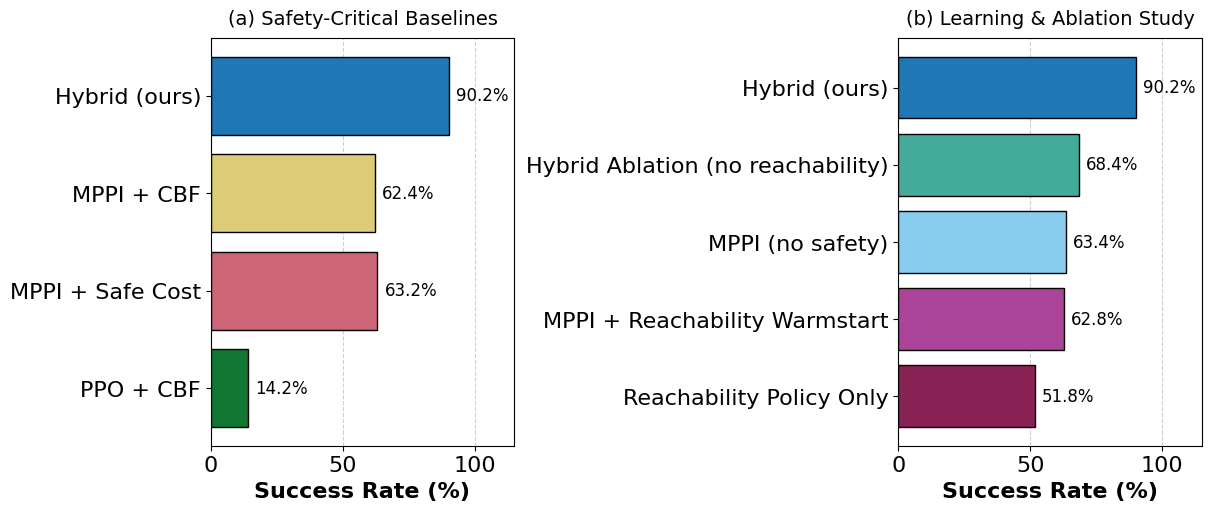

In [ ]:
# import matplotlib.pyplot as plt
# import pathlib

# # 1. Setup figure with 2 subplots (1 row, 2 columns)
# # Sharey=False because the labels on the Y-axis (controller names) are different
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), layout='constrained')

# # Global Font Settings for Readability
# plt.rcParams.update({'font.size': 12})

# # --- Subplot 1: Ours vs Safe Baselines ---
# controller_names_safe = ['Hybrid (ours)', 'MPPI + CBF', 'MPPI + Safe Cost', 'PPO + CBF']
# success_safe = [bar_graph_dict[key]*100 for key in controller_names_safe]
# colors_safe = [bar_graph_colors[key] for key in controller_names_safe]

# # Use barh (horizontal) to make long names easy to read
# bars1 = ax1.barh(controller_names_safe, success_safe, color=colors_safe, edgecolor='black')
# ax1.set_xlim(0, 115) # Extra room for bar labels
# ax1.set_xlabel('Success Rate (%)', fontweight='bold')
# ax1.set_title('(a) Safety-Critical Baselines', fontsize=14, pad=10)
# ax1.bar_label(bars1, fmt='%.1f%%', padding=5)
# ax1.invert_yaxis() # Put 'Hybrid (ours)' at the top

# # --- Subplot 2: Ours vs Model/Learning Combinations ---
# controller_names_learn = [
#     'Hybrid (ours)', 
#     'Hybrid Ablation (no reachability)', 
#     'MPPI (no safety)', 
#     'MPPI + Reachability Warmstart', 
#     'Reachability Policy Only'
# ]
# success_learn = [bar_graph_dict[key]*100 for key in controller_names_learn]
# colors_learn = [bar_graph_colors[key] for key in controller_names_learn]

# bars2 = ax2.barh(controller_names_learn, success_learn, color=colors_learn, edgecolor='black')
# ax2.set_xlim(0, 115)
# ax2.set_xlabel('Success Rate (%)', fontweight='bold')
# ax2.set_title('(b) Learning & Ablation Study', fontsize=14, pad=10)
# ax2.bar_label(bars2, fmt='%.1f%%', padding=5)
# ax2.invert_yaxis()

# # Final Polish
# for ax in [ax1, ax2]:
#     ax.xaxis.grid(True, linestyle='--', alpha=0.6)
#     ax.set_axisbelow(True)

# # # 2. Save as one combined PDF
# # save_folder = pathlib.Path("paper_plots")
# # save_folder.mkdir(exist_ok=True)
# # fig.savefig(save_folder / "combined_success_rates.pdf", format='pdf', bbox_inches='tight')

# plt.show()

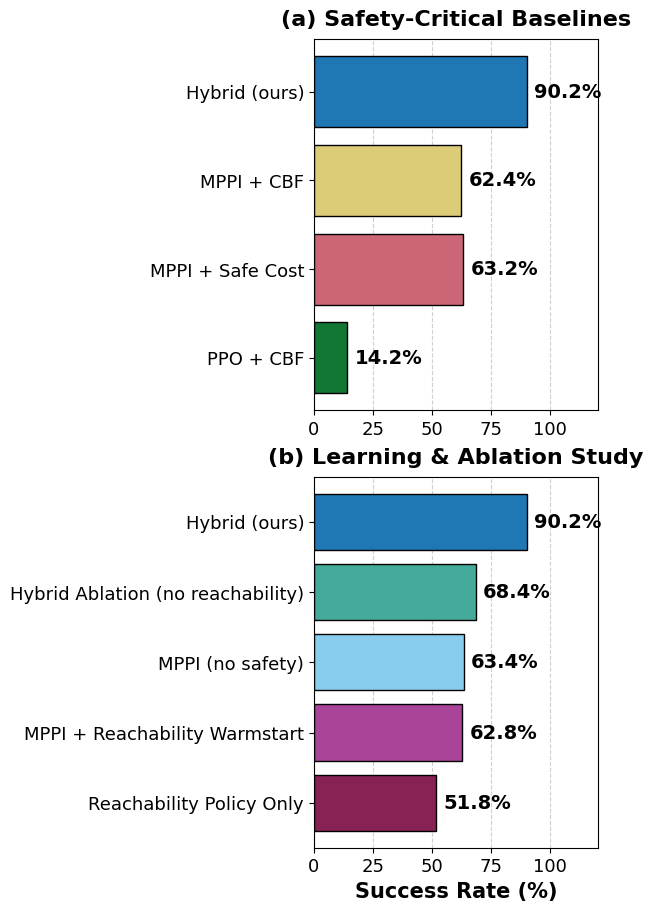

In [ ]:
# import matplotlib.pyplot as plt
# import pathlib

# # 1. Setup figure with 2 subplots stacked vertically (2 rows, 1 column)
# # Increase height (8-9) to give both plots room for their long labels
# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 9), layout='constrained')

# # Global Font Settings - Set large for single-column legibility
# plt.rcParams.update({'font.size': 14})

# # --- Subplot 1: Ours vs Safe Baselines ---
# controller_names_safe = ['Hybrid (ours)', 'MPPI + CBF', 'MPPI + Safe Cost', 'PPO + CBF']
# success_safe = [bar_graph_dict[key]*100 for key in controller_names_safe]
# colors_safe = [bar_graph_colors[key] for key in controller_names_safe]

# bars1 = ax1.barh(controller_names_safe, success_safe, color=colors_safe, edgecolor='black')
# ax1.set_xlim(0, 120) 
# ax1.set_title('(a) Safety-Critical Baselines', fontsize=16, fontweight='bold', pad=10)
# ax1.bar_label(bars1, fmt='%.1f%%', padding=5, fontweight='bold')
# ax1.invert_yaxis() 

# # --- Subplot 2: Ours vs Model/Learning Combinations ---
# controller_names_learn = [
#     'Hybrid (ours)', 
#     'Hybrid Ablation (no reachability)', # Shortened slightly for width
#     'MPPI (no safety)', 
#     'MPPI + Reachability Warmstart', 
#     'Reachability Policy Only'
# ]
# success_learn = [bar_graph_dict[key]*100 for key in controller_names_learn]
# colors_learn = [bar_graph_colors[key] for key in controller_names_learn]

# bars2 = ax2.barh(controller_names_learn, success_learn, color=colors_learn, edgecolor='black')
# ax2.set_xlim(0, 120)
# ax2.set_title('(b) Learning & Ablation Study', fontsize=16, fontweight='bold', pad=10)
# ax2.bar_label(bars2, fmt='%.1f%%', padding=5, fontweight='bold')
# ax2.invert_yaxis()

# # Common X-label on the bottom plot only to save space
# ax2.set_xlabel('Success Rate (%)', fontsize=15, fontweight='bold')

# # Styling
# for ax in [ax1, ax2]:
#     ax.xaxis.grid(True, linestyle='--', alpha=0.6)
#     ax.set_axisbelow(True)
#     ax.tick_params(axis='both', labelsize=13)

# # 2. Save
# save_path = pathlib.Path("paper_plots") / "stacked_success_rates.pdf"
# fig.savefig(save_path, format='pdf', bbox_inches='tight')

# plt.show()

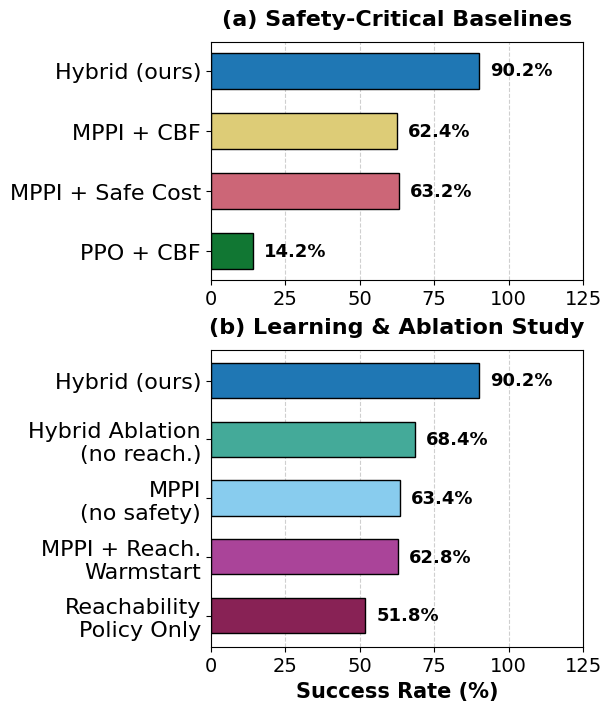

In [ ]:
# import matplotlib.pyplot as plt
# import pathlib

# # 1. Setup figure: 2 rows, 1 column. 
# # We use height_ratios=[4, 5] because plot A has 4 bars and plot B has 5.
# # This keeps the bar thickness identical between the two subplots.
# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 7), layout='constrained', 
#                                gridspec_kw={'height_ratios': [4, 5]})

# # Global Font Settings - Set large for single-column legibility
# plt.rcParams.update({'font.size': 18})
# bar_height = 0.6  # Adjust this (0.1 to 0.9) to make bars thinner or thicker

# # --- Subplot 1: Ours vs Safe Baselines ---
# controller_names_safe = ['Hybrid (ours)', 'MPPI + CBF', 'MPPI + Safe Cost', 'PPO + CBF']
# success_safe = [bar_graph_dict[key]*100 for key in controller_names_safe]
# colors_safe = [bar_graph_colors[key] for key in controller_names_safe]

# bars1 = ax1.barh(controller_names_safe, success_safe, height=bar_height, 
#                  color=colors_safe, edgecolor='black')
# ax1.set_xlim(0, 125) # More room for the 'huge' labels
# ax1.set_title('(a) Safety-Critical Baselines', fontsize=16, fontweight='bold', pad=12)
# ax1.bar_label(bars1, fmt='%.1f%%', padding=8, fontweight='bold', fontsize=13)
# ax1.invert_yaxis() 

# # --- Subplot 2: Ours vs Model/Learning Combinations ---
# controller_names_learn = [
#     'Hybrid (ours)', 
#     'Hybrid Ablation (no reachability)', # Shortened slightly for column width
#     'MPPI (no safety)', 
#     'MPPI + Reachability Warmstart', 
#     'Reachability Policy Only'
# ]
# controller_names_learn_graph = [
#     'Hybrid (ours)', 
#     'Hybrid Ablation\n(no reach.)', # Shortened slightly for column width
#     'MPPI\n(no safety)', 
#     'MPPI + Reach.\nWarmstart', 
#     'Reachability\nPolicy Only'
# ]
# success_learn = [bar_graph_dict[key]*100 for key in controller_names_learn]
# colors_learn = [bar_graph_colors[key] for key in controller_names_learn]

# bars2 = ax2.barh(controller_names_learn_graph, success_learn, height=bar_height, 
#                  color=colors_learn, edgecolor='black')
# ax2.set_xlim(0, 125)
# ax2.set_xlabel('Success Rate (%)', fontsize=15, fontweight='bold')
# ax2.set_title('(b) Learning & Ablation Study', fontsize=16, fontweight='bold', pad=12)
# ax2.bar_label(bars2, fmt='%.1f%%', padding=8, fontweight='bold', fontsize=13)
# ax2.invert_yaxis()

# # Final Polish
# for ax in [ax1, ax2]:
#     ax.xaxis.grid(True, linestyle='--', alpha=0.6)
#     ax.set_axisbelow(True)
#     # Make tick labels (controller names) bigger
#     ax.tick_params(axis='y', labelsize=16)
#     ax.tick_params(axis='x', labelsize=14)

# # 2. Save as one combined PDF
# save_folder = pathlib.Path("paper_plots")
# save_folder.mkdir(exist_ok=True)
# fig.savefig(save_folder / "stacked_success_rates.pdf", format='pdf', bbox_inches='tight')

# plt.show()